<a href="https://colab.research.google.com/github/marclamberts/football-analysis/blob/main/Compare_CB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


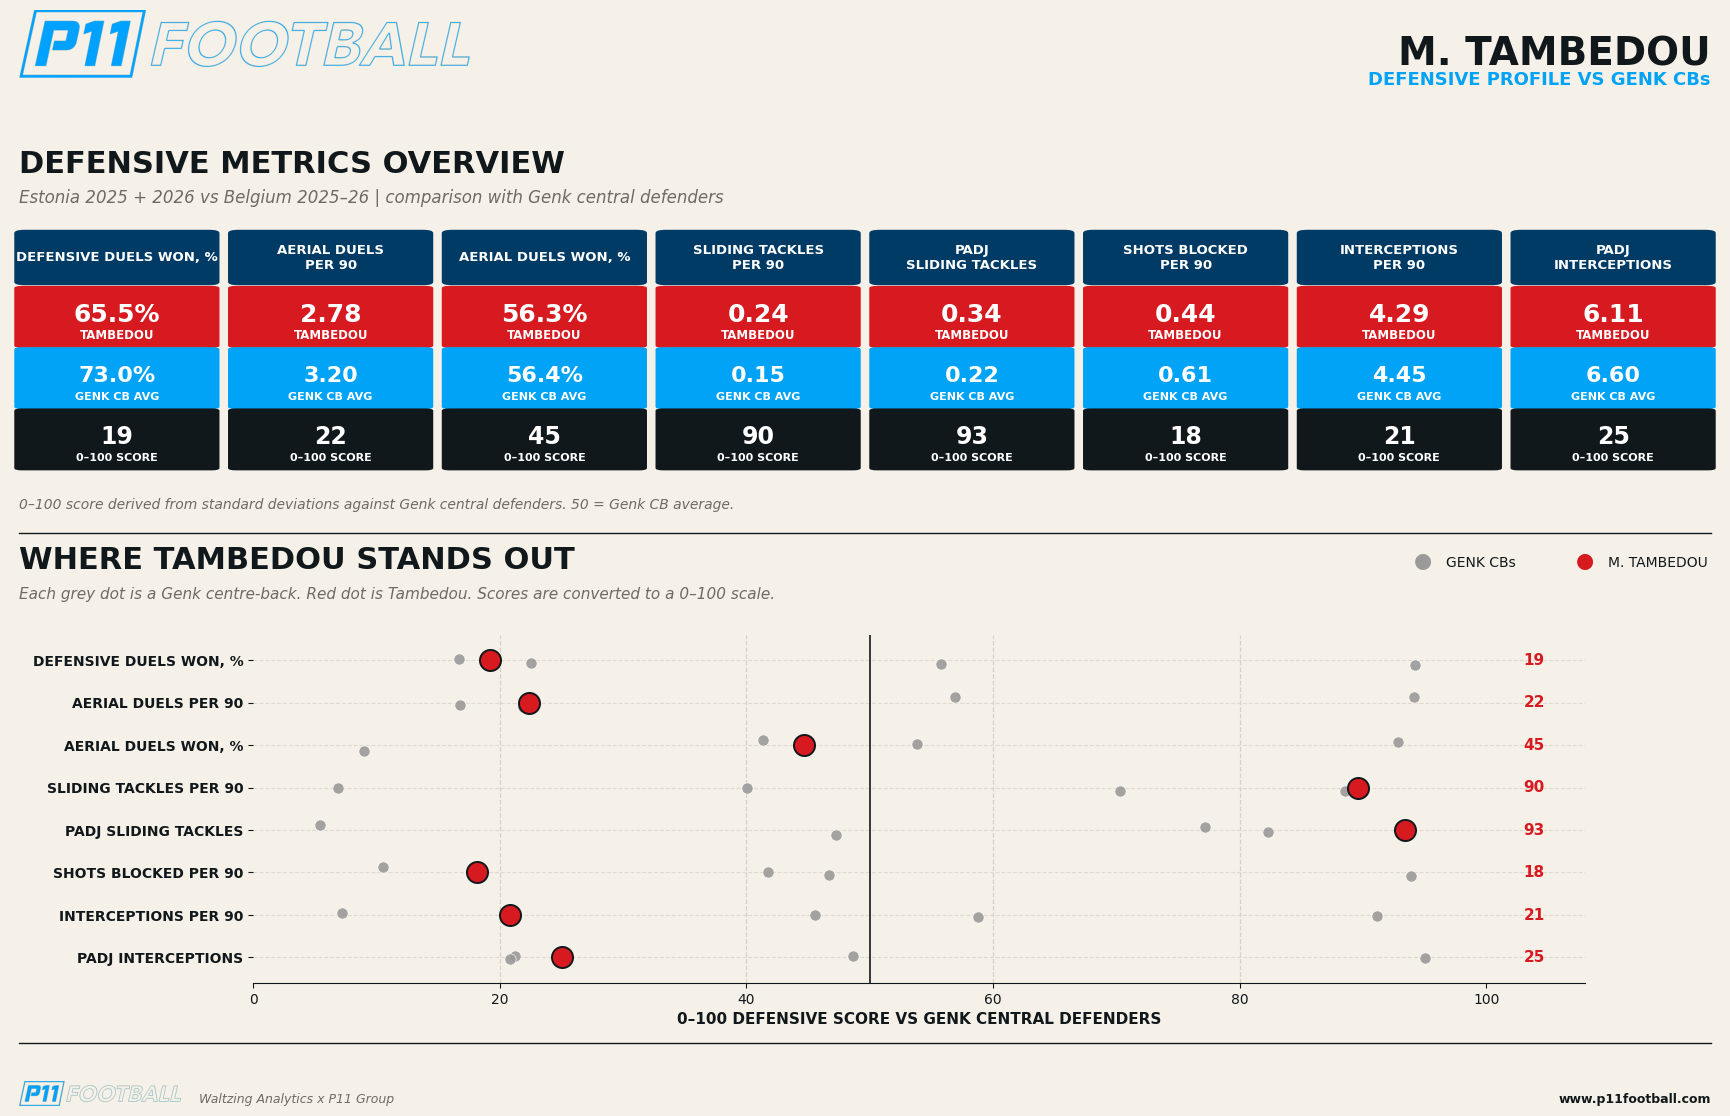

Saved to: /content/drive/MyDrive/P11/p11_tambedou_genk_dashboard.png


In [12]:
# =========================
# P11-style dashboard
# Colored metric tiles + 0–100 beeswarm
# No radar
# Google Colab / one cell
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageChops
from scipy.stats import norm

BASE = "/content/drive/MyDrive/P11/Wyscout/"

FILES = {
    "Belgium 2025-2026": "Belgium 2025-2026.xlsx",
    "Estonia 2025": "Estonia 2025.xlsx",
    "Estonia 2026": "Estonia 2026.xlsx",
}

LOGO_NAME = "P11-Football-Logo.png"

metrics = [
    "Defensive duels won, %",
    "Aerial duels per 90",
    "Aerial duels won, %",
    "Sliding tackles per 90",
    "PAdj Sliding tackles",
    "Shots blocked per 90",
    "Interceptions per 90",
    "PAdj Interceptions",
]

def find_file(filename):
    direct = os.path.join(BASE, filename)
    if os.path.exists(direct):
        return direct

    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find: {filename}")

frames = []
for label, fn in FILES.items():
    df = pd.read_excel(find_file(fn))
    df["Dataset"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
metrics = [m for m in metrics if m in data.columns]

def is_cb(pos):
    pos = str(pos).upper()
    return any(x in pos for x in ["CB", "LCB", "RCB"])

tamb = data[
    (data["Player"].astype(str).str.lower().str.strip() == "m. tambedou") &
    (data["Dataset"].isin(["Estonia 2025", "Estonia 2026"]))
].copy()

genk = data[
    (data["Dataset"] == "Belgium 2025-2026") &
    (data["Team"].astype(str).str.contains("Genk", case=False, na=False)) &
    (data["Position"].apply(is_cb))
].copy()

MIN_MINUTES = 0

tamb = tamb[pd.to_numeric(tamb["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]
genk = genk[pd.to_numeric(genk["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]

def weighted_profile(df, name, group):
    mins = pd.to_numeric(df["Minutes played"], errors="coerce").fillna(0)

    out = {
        "Player": name,
        "Group": group,
        "Minutes played": mins.sum()
    }

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce")

        if mins.sum() > 0:
            out[m] = np.average(vals.fillna(vals.mean()), weights=mins)
        else:
            out[m] = vals.mean()

    return out

rows = [weighted_profile(tamb, "M. Tambedou", "Tambedou")]

for _, r in genk.iterrows():
    row = {
        "Player": r["Player"],
        "Group": "Genk CB",
        "Minutes played": r["Minutes played"]
    }

    for m in metrics:
        row[m] = pd.to_numeric(r[m], errors="coerce")

    rows.append(row)

compare = pd.DataFrame(rows)

genk_avg = weighted_profile(genk, "Genk CB average", "Genk average")

compare = pd.concat(
    [compare, pd.DataFrame([genk_avg])],
    ignore_index=True
)

tamb_row = compare[compare["Group"] == "Tambedou"].iloc[0]
genk_rows = compare[compare["Group"] == "Genk CB"].copy()
genk_avg_row = compare[compare["Group"] == "Genk average"].iloc[0]

# =========================
# 0–100 SCORES
# 50 = Genk CB average
# =========================

tile_rows = []
score_rows = []

for m in metrics:
    vals = pd.to_numeric(genk_rows[m], errors="coerce")
    mu = vals.mean()
    sd = vals.std(ddof=0)

    tamb_val = tamb_row[m]
    avg_val = genk_avg_row[m]

    tamb_z = 0 if sd == 0 or pd.isna(sd) else (tamb_val - mu) / sd
    tamb_score = norm.cdf(tamb_z) * 100

    tile_rows.append({
        "Metric": m,
        "Tambedou": tamb_val,
        "Genk Avg": avg_val,
        "Diff": tamb_val - avg_val,
        "Score": tamb_score
    })

    for _, r in genk_rows.iterrows():
        player_val = pd.to_numeric(r[m], errors="coerce")
        player_z = 0 if sd == 0 or pd.isna(sd) else (player_val - mu) / sd
        player_score = norm.cdf(player_z) * 100

        score_rows.append({
            "Player": r["Player"],
            "Group": "Genk CB",
            "Metric": m,
            "Score": player_score
        })

    score_rows.append({
        "Player": "M. Tambedou",
        "Group": "Tambedou",
        "Metric": m,
        "Score": tamb_score
    })

tile_df = pd.DataFrame(tile_rows)
score_df = pd.DataFrame(score_rows)

# =========================
# STYLE
# =========================

bg = "#F6F1E8"
ink = "#11181C"
muted = "#6F6A62"
p11_blue = "#00A3F5"
navy = "#003B66"
red = "#D71920"
grey = "#9A9A9A"
light_grey = "#D7D0C4"

plt.rcParams.update({
    "figure.facecolor": bg,
    "axes.facecolor": bg,
    "savefig.facecolor": bg,
    "font.family": "DejaVu Sans",
    "axes.edgecolor": ink,
    "axes.labelcolor": ink,
    "xtick.color": ink,
    "ytick.color": ink,
    "text.color": ink,
})

def clean_metric(m):
    return (
        m.upper()
        .replace(" PER 90", "\nPER 90")
        .replace("PADJ ", "PADJ\n")
    )

def trim_logo(im):
    bg_img = Image.new("RGBA", im.size, (0, 0, 0, 0))
    diff = ImageChops.difference(im, bg_img)
    bbox = diff.getbbox()
    return im.crop(bbox) if bbox else im

def add_logo_axes(fig, rect):
    try:
        logo_path = find_file(LOGO_NAME)
        logo = Image.open(logo_path).convert("RGBA")
        logo = trim_logo(logo)

        ax_logo = fig.add_axes(rect)
        ax_logo.imshow(logo)
        ax_logo.axis("off")
        return ax_logo

    except Exception as e:
        print(f"Logo error: {e}")

# =========================
# DASHBOARD
# =========================

fig = plt.figure(figsize=(18, 12), facecolor=bg)

add_logo_axes(fig, [0.03, 0.885, 0.25, 0.085])

fig.text(
    0.97, 0.935,
    "M. TAMBEDOU",
    ha="right",
    va="top",
    fontsize=28,
    weight="bold",
    color=ink
)

fig.text(
    0.97, 0.905,
    "DEFENSIVE PROFILE VS GENK CBs",
    ha="right",
    va="top",
    fontsize=13,
    weight="bold",
    color=p11_blue
)

fig.text(
    0.03, 0.820,
    "DEFENSIVE METRICS OVERVIEW",
    fontsize=22,
    weight="bold",
    color=ink
)

fig.text(
    0.03, 0.795,
    "Estonia 2025 + 2026 vs Belgium 2025–26 | comparison with Genk central defenders",
    fontsize=12,
    style="italic",
    color=muted
)

# =========================
# COLORED TILE TABLE
# =========================

tile_ax = fig.add_axes([0.025, 0.565, 0.95, 0.215])
tile_ax.set_xlim(0, len(metrics))
tile_ax.set_ylim(0, 4)
tile_ax.axis("off")

for i, row in tile_df.iterrows():
    x = i
    m = row["Metric"]

    header = FancyBboxPatch(
        (x + 0.04, 3.02),
        0.92,
        0.82,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=0,
        facecolor=navy
    )
    tile_ax.add_patch(header)

    tile_ax.text(
        x + 0.50,
        3.43,
        clean_metric(m),
        ha="center",
        va="center",
        fontsize=9.5,
        weight="bold",
        color="white"
    )

    tbox = FancyBboxPatch(
        (x + 0.04, 2.05),
        0.92,
        0.92,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        linewidth=0,
        facecolor=red
    )
    tile_ax.add_patch(tbox)

    tile_ax.text(
        x + 0.50,
        2.55,
        f"{row['Tambedou']:.2f}" if "%" not in m else f"{row['Tambedou']:.1f}%",
        ha="center",
        va="center",
        fontsize=18,
        weight="bold",
        color="white"
    )

    tile_ax.text(
        x + 0.50,
        2.22,
        "TAMBEDOU",
        ha="center",
        va="center",
        fontsize=8.5,
        weight="bold",
        color="white"
    )

    gbox = FancyBboxPatch(
        (x + 0.04, 1.10),
        0.92,
        0.92,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        linewidth=0,
        facecolor=p11_blue
    )
    tile_ax.add_patch(gbox)

    tile_ax.text(
        x + 0.50,
        1.60,
        f"{row['Genk Avg']:.2f}" if "%" not in m else f"{row['Genk Avg']:.1f}%",
        ha="center",
        va="center",
        fontsize=16,
        weight="bold",
        color="white"
    )

    tile_ax.text(
        x + 0.50,
        1.27,
        "GENK CB AVG",
        ha="center",
        va="center",
        fontsize=8,
        weight="bold",
        color="white"
    )

    score_box = FancyBboxPatch(
        (x + 0.04, 0.15),
        0.92,
        0.92,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        linewidth=0,
        facecolor=ink
    )
    tile_ax.add_patch(score_box)

    tile_ax.text(
        x + 0.50,
        0.65,
        f"{row['Score']:.0f}",
        ha="center",
        va="center",
        fontsize=17,
        weight="bold",
        color="white"
    )

    tile_ax.text(
        x + 0.50,
        0.32,
        "0–100 SCORE",
        ha="center",
        va="center",
        fontsize=8,
        weight="bold",
        color="white"
    )

fig.text(
    0.03,
    0.540,
    "0–100 score derived from standard deviations against Genk central defenders. 50 = Genk CB average.",
    fontsize=10,
    style="italic",
    color=muted
)

fig.lines.append(
    plt.Line2D(
        [0.03, 0.97],
        [0.520, 0.520],
        transform=fig.transFigure,
        color=ink,
        linewidth=1
    )
)

# =========================
# BEESWARM 0–100
# =========================

fig.text(
    0.03,
    0.490,
    "WHERE TAMBEDOU STANDS OUT",
    fontsize=22,
    weight="bold",
    color=ink
)

fig.text(
    0.03,
    0.465,
    "Each grey dot is a Genk centre-back. Red dot is Tambedou. Scores are converted to a 0–100 scale.",
    fontsize=11,
    style="italic",
    color=muted
)

fig.text(0.805, 0.492, "●", color=grey, fontsize=15)
fig.text(0.823, 0.492, "GENK CBs", fontsize=10, color=ink)
fig.text(0.895, 0.492, "●", color=red, fontsize=15)
fig.text(0.913, 0.492, "M. TAMBEDOU", fontsize=10, color=ink)

ax = fig.add_axes([0.16, 0.145, 0.74, 0.29])

for i, m in enumerate(metrics):
    subset = score_df[score_df["Metric"] == m].copy()

    genk_subset = subset[subset["Group"] == "Genk CB"].reset_index(drop=True)
    tamb_subset = subset[subset["Group"] == "Tambedou"]

    rng = np.random.default_rng(42 + i)
    jitter = rng.uniform(-0.15, 0.15, len(genk_subset))

    ax.scatter(
        genk_subset["Score"],
        i + jitter,
        s=65,
        color=grey,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

    score = float(tamb_subset["Score"].iloc[0])

    ax.scatter(
        score,
        i,
        s=230,
        color=red,
        edgecolor=ink,
        linewidth=1.4,
        zorder=5
    )

    ax.text(
        103,
        i,
        f"{score:.0f}",
        va="center",
        ha="left",
        fontsize=11,
        weight="bold",
        color=red
    )

ax.axvline(50, color=ink, lw=1.2)

for x in [20, 40, 60, 80]:
    ax.axvline(
        x,
        color=light_grey,
        lw=0.9,
        ls="--",
        zorder=1
    )

ax.set_xlim(0, 108)
ax.set_ylim(-0.6, len(metrics) - 0.4)

ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(
    [m.upper().replace(" PER 90", " PER 90") for m in metrics],
    fontsize=10,
    weight="bold"
)

ax.set_xlabel(
    "0–100 DEFENSIVE SCORE VS GENK CENTRAL DEFENDERS",
    fontsize=11,
    weight="bold"
)

ax.invert_yaxis()
ax.grid(
    axis="y",
    color=light_grey,
    linestyle="--",
    linewidth=0.8,
    alpha=0.7
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# =========================
# FOOTER
# =========================

fig.lines.append(
    plt.Line2D(
        [0.03, 0.97],
        [0.095, 0.095],
        transform=fig.transFigure,
        color=ink,
        linewidth=1
    )
)

add_logo_axes(fig, [0.03, 0.035, 0.09, 0.035])

fig.text(
    0.13,
    0.045,
    "Waltzing Analytics x P11 Group",
    fontsize=9,
    style="italic",
    color=muted
)

fig.text(
    0.97,
    0.045,
    "www.p11football.com",
    ha="right",
    fontsize=9,
    weight="bold",
    color=ink
)

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

output_path = "/content/drive/MyDrive/P11/p11_tambedou_genk_dashboard.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


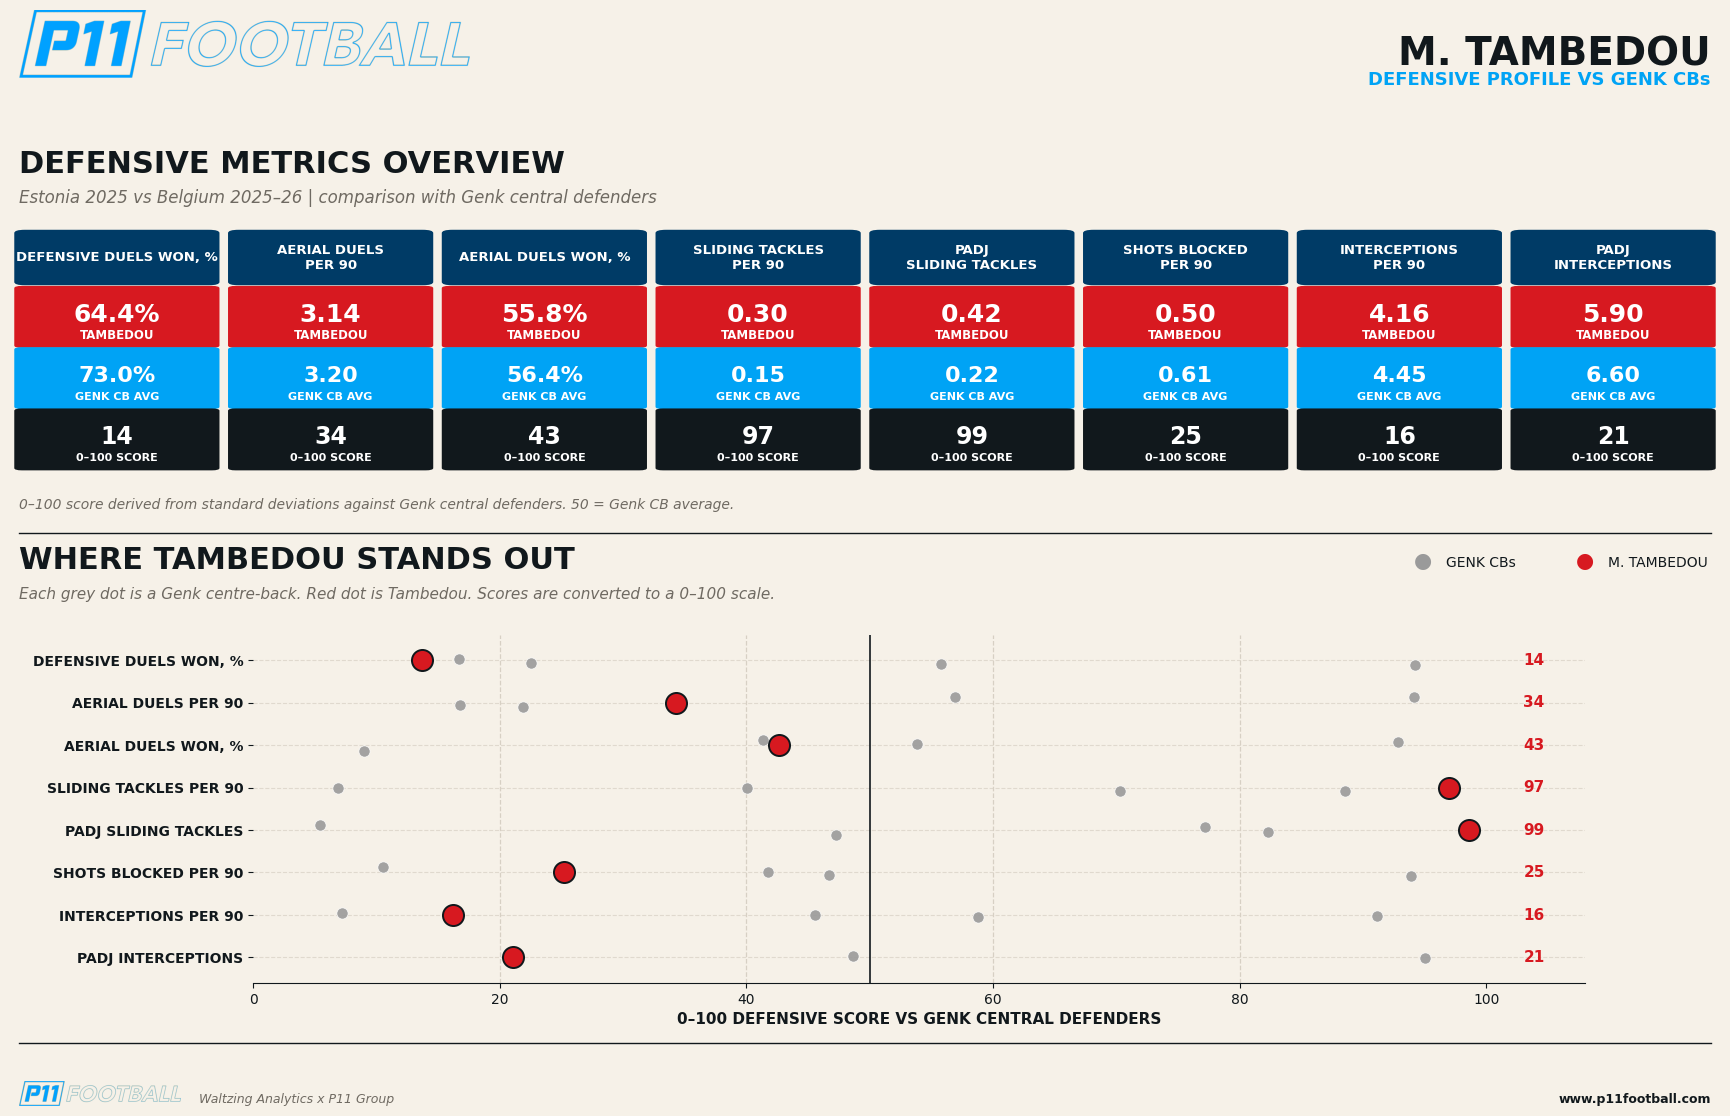

Saved to: /content/p11_tambedou_genk_dashboard_Estonia_2025.png


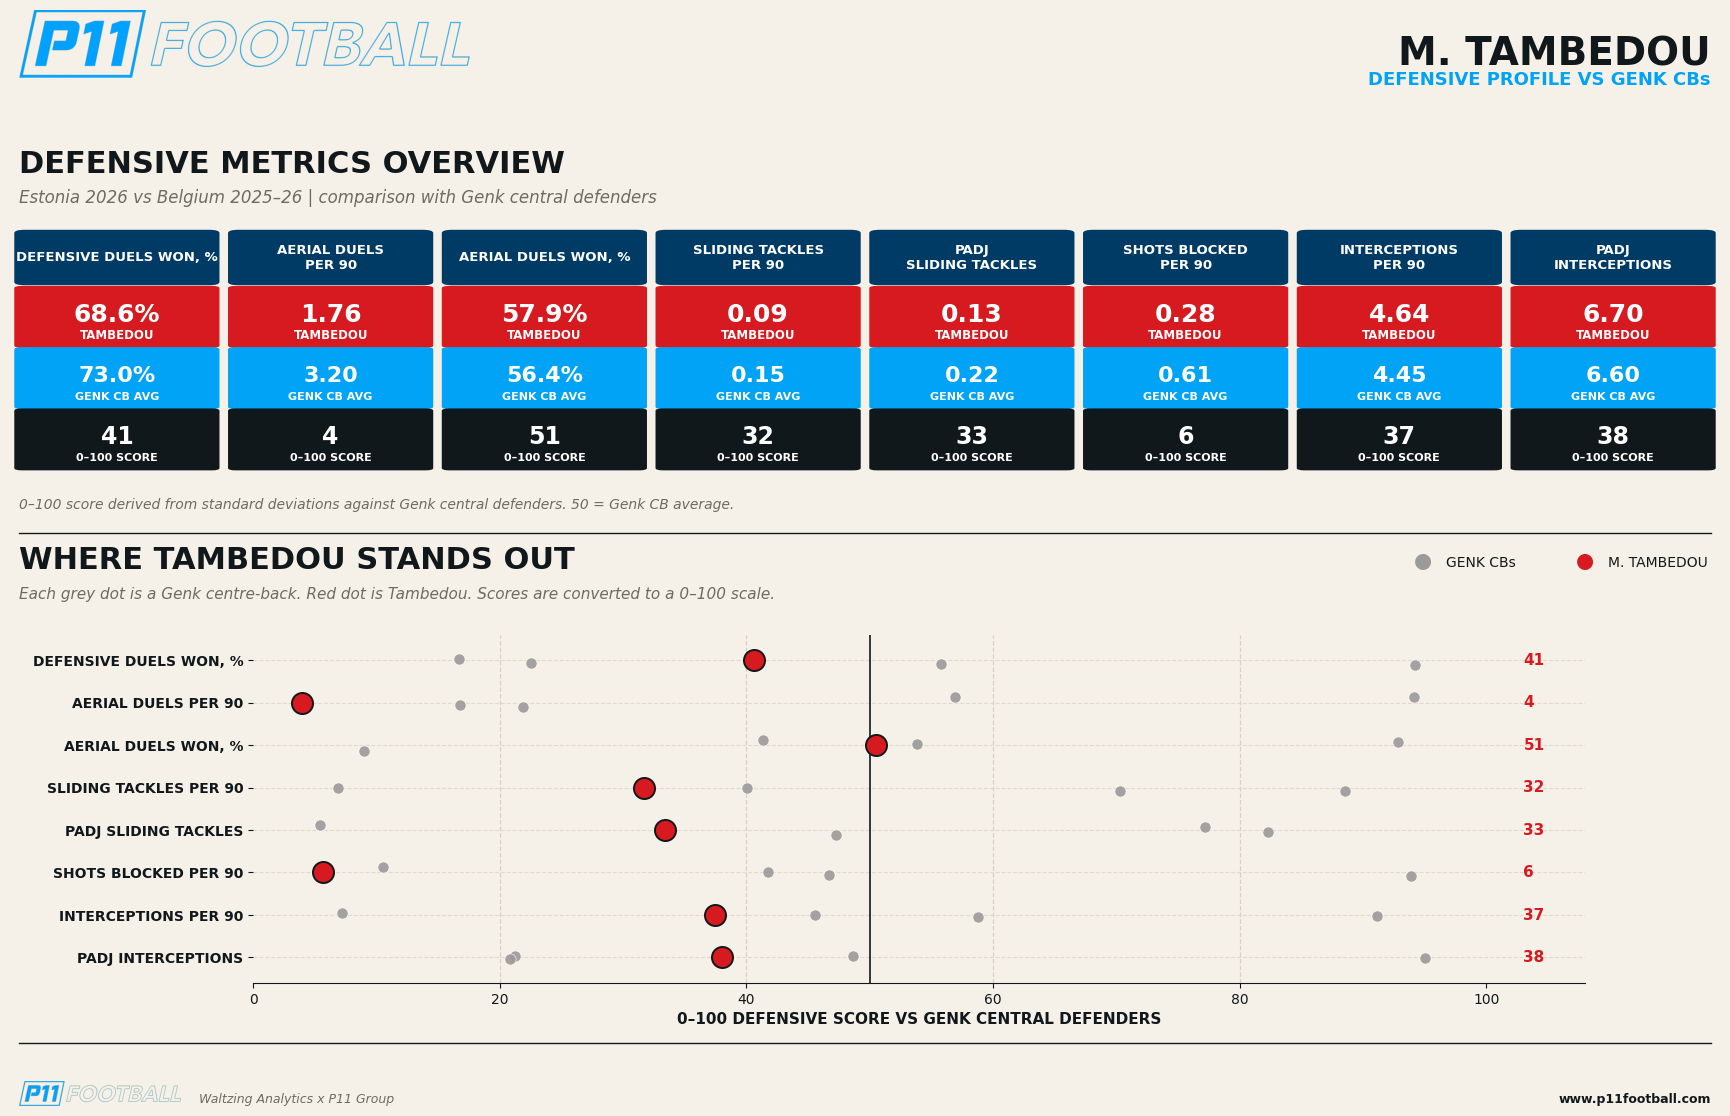

Saved to: /content/p11_tambedou_genk_dashboard_Estonia_2026.png


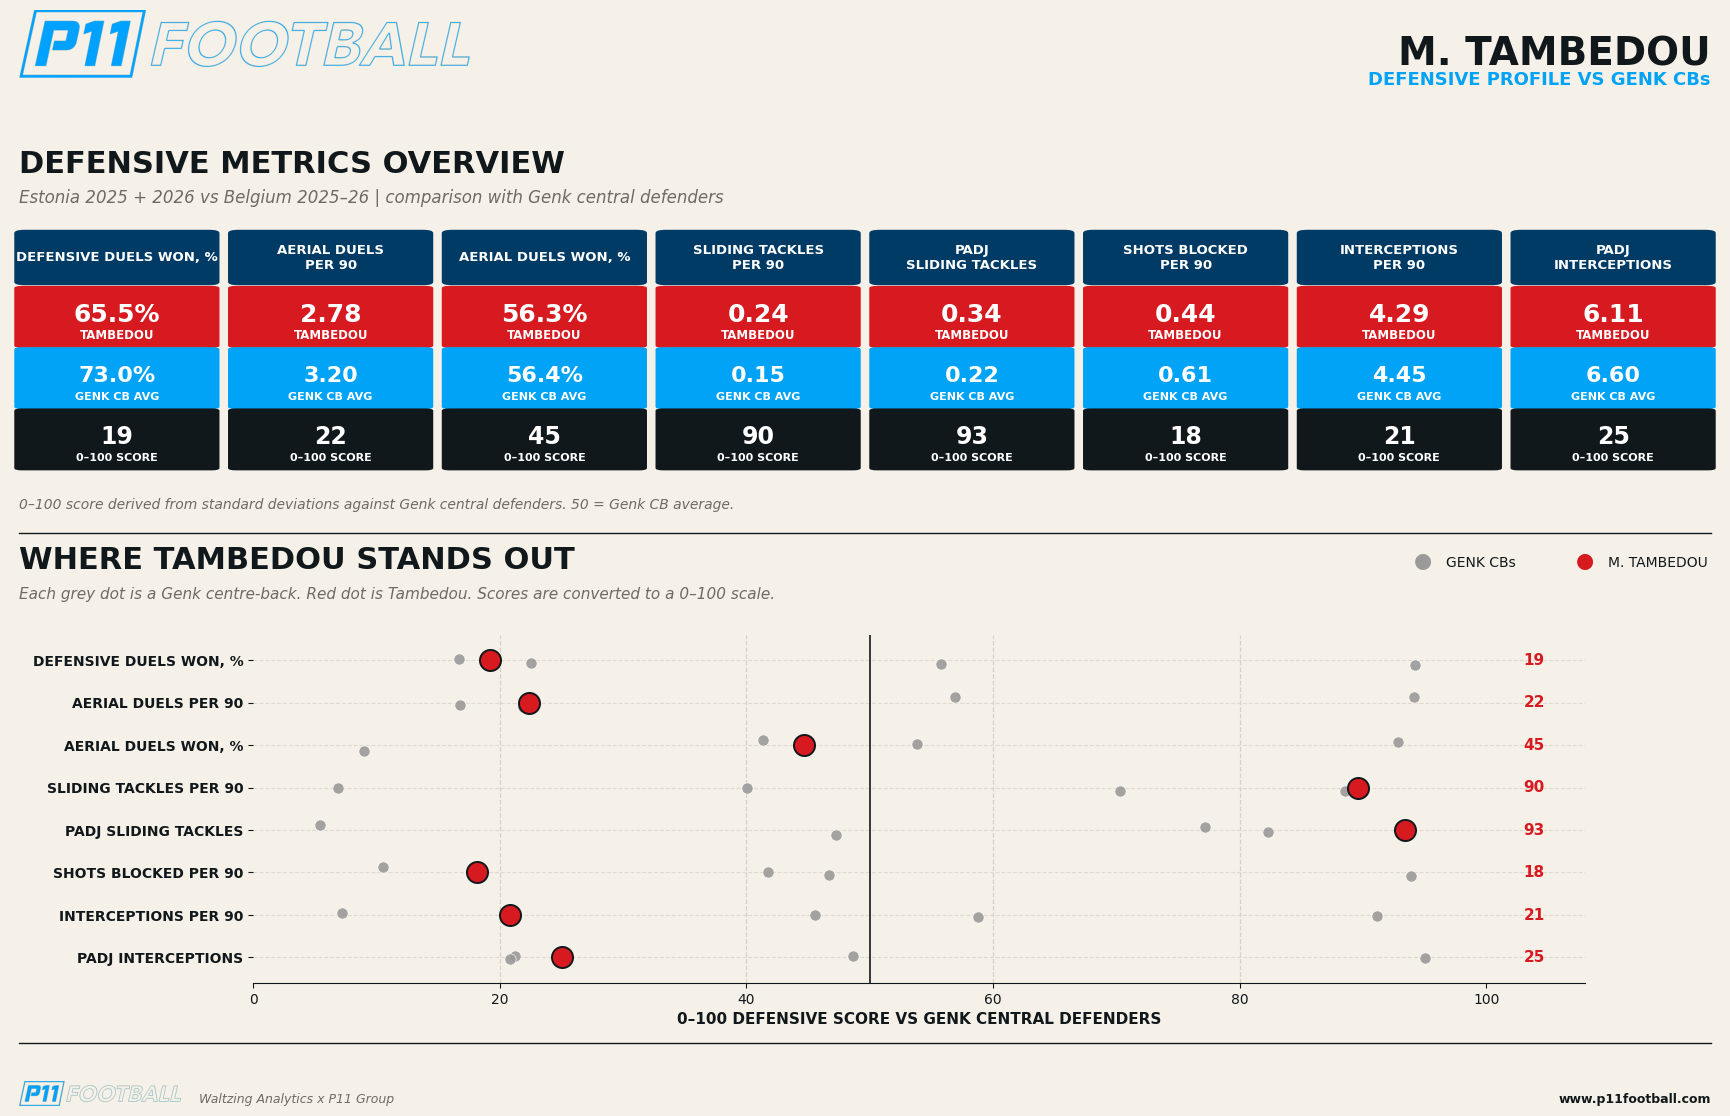

Saved to: /content/p11_tambedou_genk_dashboard_Estonia_2025_plus_2026.png


In [13]:
# =========================
# P11-style dashboards
# 3 visuals:
# 1) Estonia 2025
# 2) Estonia 2026
# 3) Estonia 2025 + 2026
# Colored metric tiles + 0–100 beeswarm
# No radar
# Google Colab / one cell
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageChops
from scipy.stats import norm

BASE = "/content/drive/MyDrive/P11/Wyscout/"

FILES = {
    "Belgium 2025-2026": "Belgium 2025-2026.xlsx",
    "Estonia 2025": "Estonia 2025.xlsx",
    "Estonia 2026": "Estonia 2026.xlsx",
}

LOGO_NAME = "P11-Football-Logo.png"

metrics = [
    "Defensive duels won, %",
    "Aerial duels per 90",
    "Aerial duels won, %",
    "Sliding tackles per 90",
    "PAdj Sliding tackles",
    "Shots blocked per 90",
    "Interceptions per 90",
    "PAdj Interceptions",
]

def find_file(filename):
    direct = os.path.join(BASE, filename)
    if os.path.exists(direct):
        return direct
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Could not find: {filename}")

frames = []
for label, fn in FILES.items():
    df = pd.read_excel(find_file(fn))
    df["Dataset"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
metrics = [m for m in metrics if m in data.columns]

def is_cb(pos):
    pos = str(pos).upper()
    return any(x in pos for x in ["CB", "LCB", "RCB"])

def trim_logo(im):
    bg_img = Image.new("RGBA", im.size, (0, 0, 0, 0))
    diff = ImageChops.difference(im, bg_img)
    bbox = diff.getbbox()
    return im.crop(bbox) if bbox else im

def add_logo_axes(fig, rect):
    try:
        logo_path = find_file(LOGO_NAME)
        logo = Image.open(logo_path).convert("RGBA")
        logo = trim_logo(logo)
        ax_logo = fig.add_axes(rect)
        ax_logo.imshow(logo)
        ax_logo.axis("off")
    except Exception as e:
        print(f"Logo error: {e}")

def clean_metric(m):
    return (
        m.upper()
        .replace(" PER 90", "\nPER 90")
        .replace("PADJ ", "PADJ\n")
    )

def weighted_profile(df, name, group):
    mins = pd.to_numeric(df["Minutes played"], errors="coerce").fillna(0)

    out = {
        "Player": name,
        "Group": group,
        "Minutes played": mins.sum()
    }

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce")
        if mins.sum() > 0:
            out[m] = np.average(vals.fillna(vals.mean()), weights=mins)
        else:
            out[m] = vals.mean()

    return out

def make_dashboard(scenario_name, tambedou_datasets):
    MIN_MINUTES = 0

    tamb = data[
        (data["Player"].astype(str).str.lower().str.strip() == "m. tambedou") &
        (data["Dataset"].isin(tambedou_datasets))
    ].copy()

    genk = data[
        (data["Dataset"] == "Belgium 2025-2026") &
        (data["Team"].astype(str).str.contains("Genk", case=False, na=False)) &
        (data["Position"].apply(is_cb))
    ].copy()

    tamb = tamb[pd.to_numeric(tamb["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]
    genk = genk[pd.to_numeric(genk["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]

    rows = [weighted_profile(tamb, "M. Tambedou", "Tambedou")]

    for _, r in genk.iterrows():
        row = {
            "Player": r["Player"],
            "Group": "Genk CB",
            "Minutes played": r["Minutes played"]
        }

        for m in metrics:
            row[m] = pd.to_numeric(r[m], errors="coerce")

        rows.append(row)

    compare = pd.DataFrame(rows)
    genk_avg = weighted_profile(genk, "Genk CB average", "Genk average")
    compare = pd.concat([compare, pd.DataFrame([genk_avg])], ignore_index=True)

    tamb_row = compare[compare["Group"] == "Tambedou"].iloc[0]
    genk_rows = compare[compare["Group"] == "Genk CB"].copy()
    genk_avg_row = compare[compare["Group"] == "Genk average"].iloc[0]

    tile_rows = []
    score_rows = []

    for m in metrics:
        vals = pd.to_numeric(genk_rows[m], errors="coerce")
        mu = vals.mean()
        sd = vals.std(ddof=0)

        tamb_val = tamb_row[m]
        avg_val = genk_avg_row[m]

        tamb_z = 0 if sd == 0 or pd.isna(sd) else (tamb_val - mu) / sd
        tamb_score = norm.cdf(tamb_z) * 100

        tile_rows.append({
            "Metric": m,
            "Tambedou": tamb_val,
            "Genk Avg": avg_val,
            "Diff": tamb_val - avg_val,
            "Score": tamb_score
        })

        for _, r in genk_rows.iterrows():
            player_val = pd.to_numeric(r[m], errors="coerce")
            player_z = 0 if sd == 0 or pd.isna(sd) else (player_val - mu) / sd
            player_score = norm.cdf(player_z) * 100

            score_rows.append({
                "Player": r["Player"],
                "Group": "Genk CB",
                "Metric": m,
                "Score": player_score
            })

        score_rows.append({
            "Player": "M. Tambedou",
            "Group": "Tambedou",
            "Metric": m,
            "Score": tamb_score
        })

    tile_df = pd.DataFrame(tile_rows)
    score_df = pd.DataFrame(score_rows)

    bg = "#F6F1E8"
    ink = "#11181C"
    muted = "#6F6A62"
    p11_blue = "#00A3F5"
    navy = "#003B66"
    red = "#D71920"
    grey = "#9A9A9A"
    light_grey = "#D7D0C4"

    plt.rcParams.update({
        "figure.facecolor": bg,
        "axes.facecolor": bg,
        "savefig.facecolor": bg,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "text.color": ink,
    })

    fig = plt.figure(figsize=(18, 12), facecolor=bg)

    add_logo_axes(fig, [0.03, 0.885, 0.25, 0.085])

    fig.text(
        0.97, 0.935,
        "M. TAMBEDOU",
        ha="right",
        va="top",
        fontsize=28,
        weight="bold",
        color=ink
    )

    fig.text(
        0.97, 0.905,
        "DEFENSIVE PROFILE VS GENK CBs",
        ha="right",
        va="top",
        fontsize=13,
        weight="bold",
        color=p11_blue
    )

    fig.text(
        0.03, 0.820,
        "DEFENSIVE METRICS OVERVIEW",
        fontsize=22,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.795,
        f"{scenario_name} vs Belgium 2025–26 | comparison with Genk central defenders",
        fontsize=12,
        style="italic",
        color=muted
    )

    tile_ax = fig.add_axes([0.025, 0.565, 0.95, 0.215])
    tile_ax.set_xlim(0, len(metrics))
    tile_ax.set_ylim(0, 4)
    tile_ax.axis("off")

    for i, row in tile_df.iterrows():
        x = i
        m = row["Metric"]

        header = FancyBboxPatch(
            (x + 0.04, 3.02), 0.92, 0.82,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            linewidth=0,
            facecolor=navy
        )
        tile_ax.add_patch(header)

        tile_ax.text(
            x + 0.50, 3.43,
            clean_metric(m),
            ha="center",
            va="center",
            fontsize=9.5,
            weight="bold",
            color="white"
        )

        tbox = FancyBboxPatch(
            (x + 0.04, 2.05), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=red
        )
        tile_ax.add_patch(tbox)

        tile_ax.text(
            x + 0.50, 2.55,
            f"{row['Tambedou']:.2f}" if "%" not in m else f"{row['Tambedou']:.1f}%",
            ha="center",
            va="center",
            fontsize=18,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 2.22,
            "TAMBEDOU",
            ha="center",
            va="center",
            fontsize=8.5,
            weight="bold",
            color="white"
        )

        gbox = FancyBboxPatch(
            (x + 0.04, 1.10), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=p11_blue
        )
        tile_ax.add_patch(gbox)

        tile_ax.text(
            x + 0.50, 1.60,
            f"{row['Genk Avg']:.2f}" if "%" not in m else f"{row['Genk Avg']:.1f}%",
            ha="center",
            va="center",
            fontsize=16,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 1.27,
            "GENK CB AVG",
            ha="center",
            va="center",
            fontsize=8,
            weight="bold",
            color="white"
        )

        score_box = FancyBboxPatch(
            (x + 0.04, 0.15), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=ink
        )
        tile_ax.add_patch(score_box)

        tile_ax.text(
            x + 0.50, 0.65,
            f"{row['Score']:.0f}",
            ha="center",
            va="center",
            fontsize=17,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 0.32,
            "0–100 SCORE",
            ha="center",
            va="center",
            fontsize=8,
            weight="bold",
            color="white"
        )

    fig.text(
        0.03, 0.540,
        "0–100 score derived from standard deviations against Genk central defenders. 50 = Genk CB average.",
        fontsize=10,
        style="italic",
        color=muted
    )

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.520, 0.520],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    fig.text(
        0.03, 0.490,
        "WHERE TAMBEDOU STANDS OUT",
        fontsize=22,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.465,
        "Each grey dot is a Genk centre-back. Red dot is Tambedou. Scores are converted to a 0–100 scale.",
        fontsize=11,
        style="italic",
        color=muted
    )

    fig.text(0.805, 0.492, "●", color=grey, fontsize=15)
    fig.text(0.823, 0.492, "GENK CBs", fontsize=10, color=ink)
    fig.text(0.895, 0.492, "●", color=red, fontsize=15)
    fig.text(0.913, 0.492, "M. TAMBEDOU", fontsize=10, color=ink)

    ax = fig.add_axes([0.16, 0.145, 0.74, 0.29])

    for i, m in enumerate(metrics):
        subset = score_df[score_df["Metric"] == m].copy()

        genk_subset = subset[subset["Group"] == "Genk CB"].reset_index(drop=True)
        tamb_subset = subset[subset["Group"] == "Tambedou"]

        rng = np.random.default_rng(42 + i)
        jitter = rng.uniform(-0.15, 0.15, len(genk_subset))

        ax.scatter(
            genk_subset["Score"],
            i + jitter,
            s=65,
            color=grey,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        score = float(tamb_subset["Score"].iloc[0])

        ax.scatter(
            score,
            i,
            s=230,
            color=red,
            edgecolor=ink,
            linewidth=1.4,
            zorder=5
        )

        ax.text(
            103,
            i,
            f"{score:.0f}",
            va="center",
            ha="left",
            fontsize=11,
            weight="bold",
            color=red
        )

    ax.axvline(50, color=ink, lw=1.2)

    for x in [20, 40, 60, 80]:
        ax.axvline(
            x,
            color=light_grey,
            lw=0.9,
            ls="--",
            zorder=1
        )

    ax.set_xlim(0, 108)
    ax.set_ylim(-0.6, len(metrics) - 0.4)

    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(
        [m.upper().replace(" PER 90", " PER 90") for m in metrics],
        fontsize=10,
        weight="bold"
    )

    ax.set_xlabel(
        "0–100 DEFENSIVE SCORE VS GENK CENTRAL DEFENDERS",
        fontsize=11,
        weight="bold"
    )

    ax.invert_yaxis()
    ax.grid(
        axis="y",
        color=light_grey,
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.095, 0.095],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    add_logo_axes(fig, [0.03, 0.035, 0.09, 0.035])

    fig.text(
        0.13, 0.045,
        "Waltzing Analytics x P11 Group",
        fontsize=9,
        style="italic",
        color=muted
    )

    fig.text(
        0.97, 0.045,
        "www.p11football.com",
        ha="right",
        fontsize=9,
        weight="bold",
        color=ink
    )

    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    safe_name = (
        scenario_name
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("–", "-")
    )

    output_path = f"/content/p11_tambedou_genk_dashboard_{safe_name}.png"

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to: {output_path}")

SCENARIOS = {
    "Estonia 2025": ["Estonia 2025"],
    "Estonia 2026": ["Estonia 2026"],
    "Estonia 2025 + 2026": ["Estonia 2025", "Estonia 2026"],
}

for scenario_name, datasets in SCENARIOS.items():
    make_dashboard(scenario_name, datasets)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


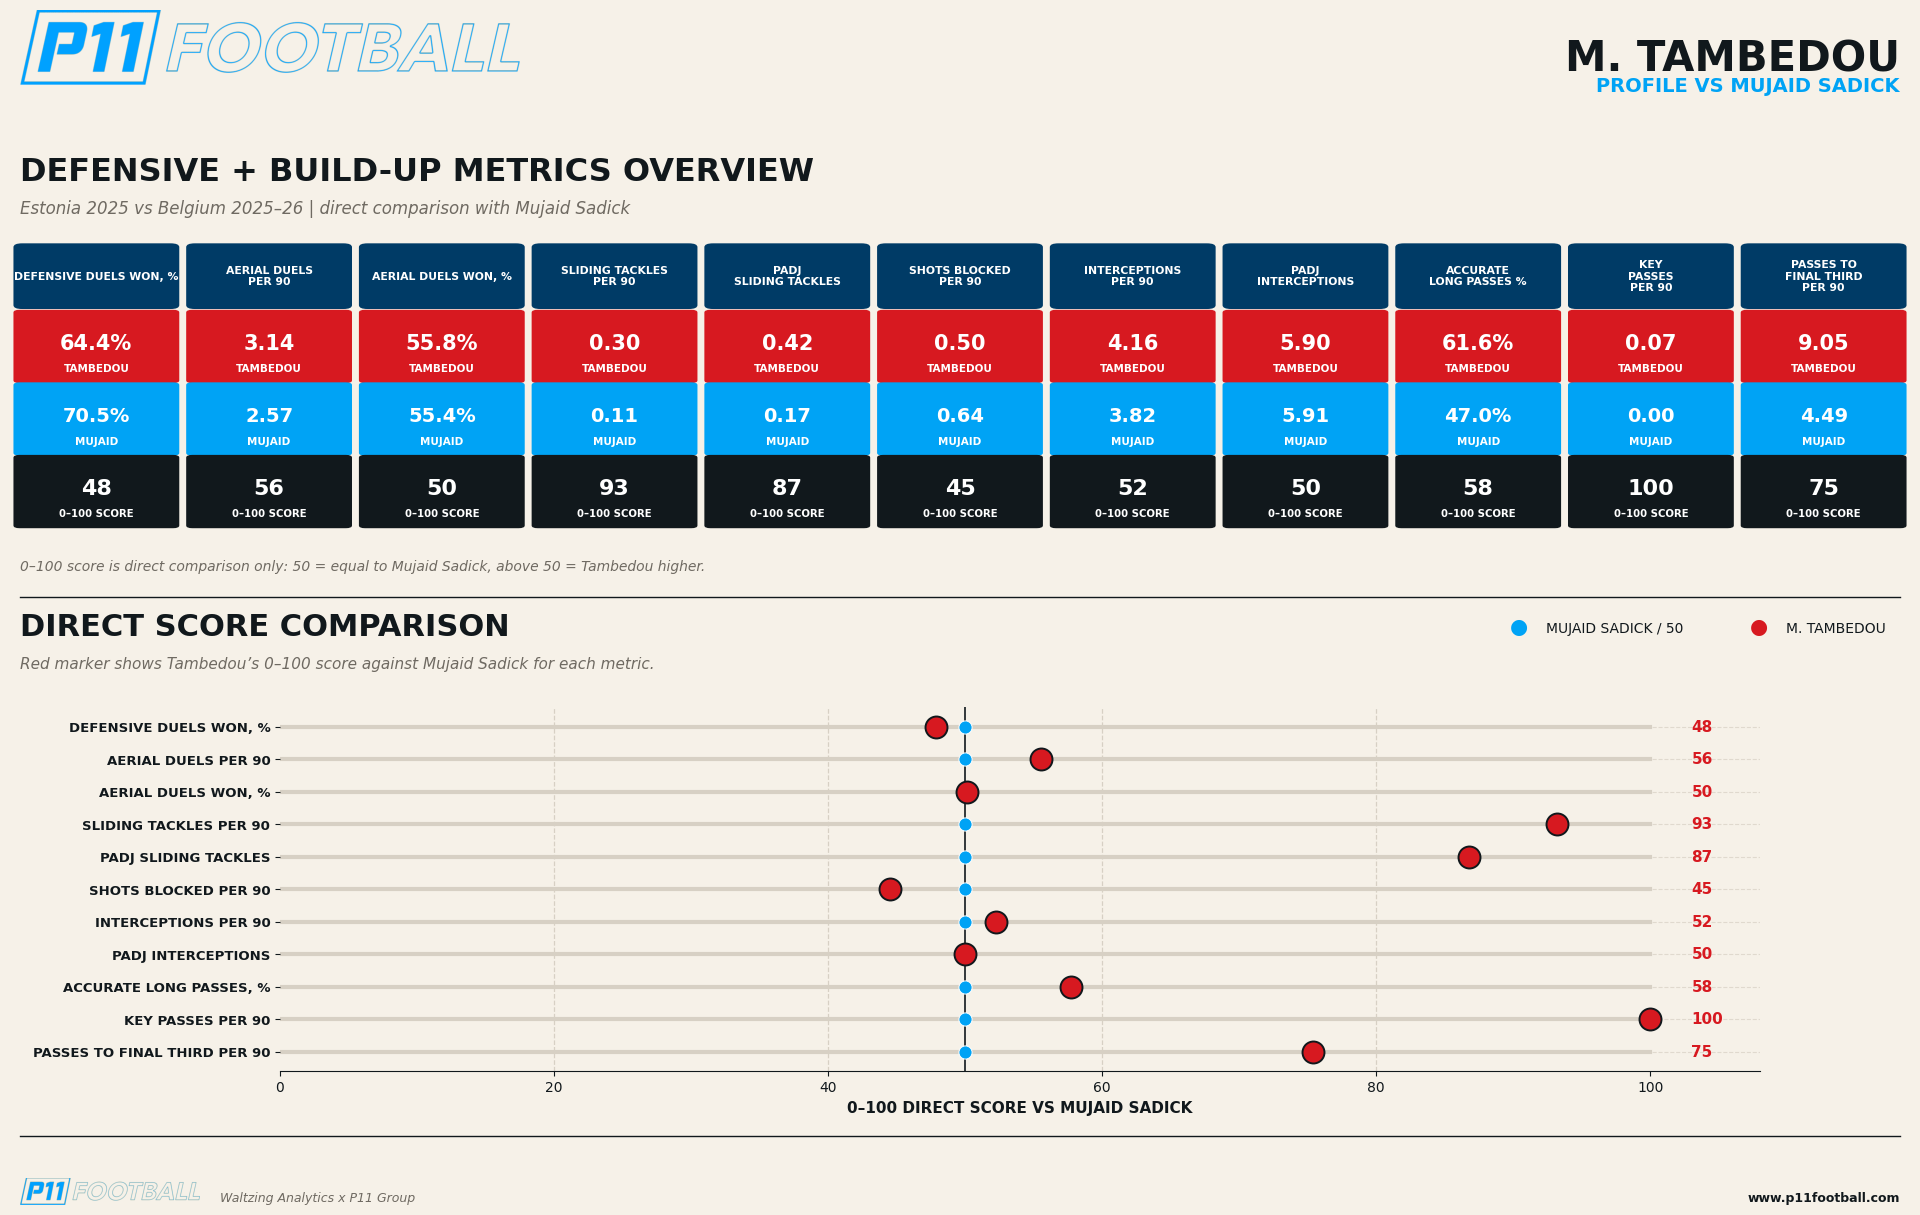

Saved to: /content/p11_tambedou_vs_mujaid_dashboard_Estonia_2025.png


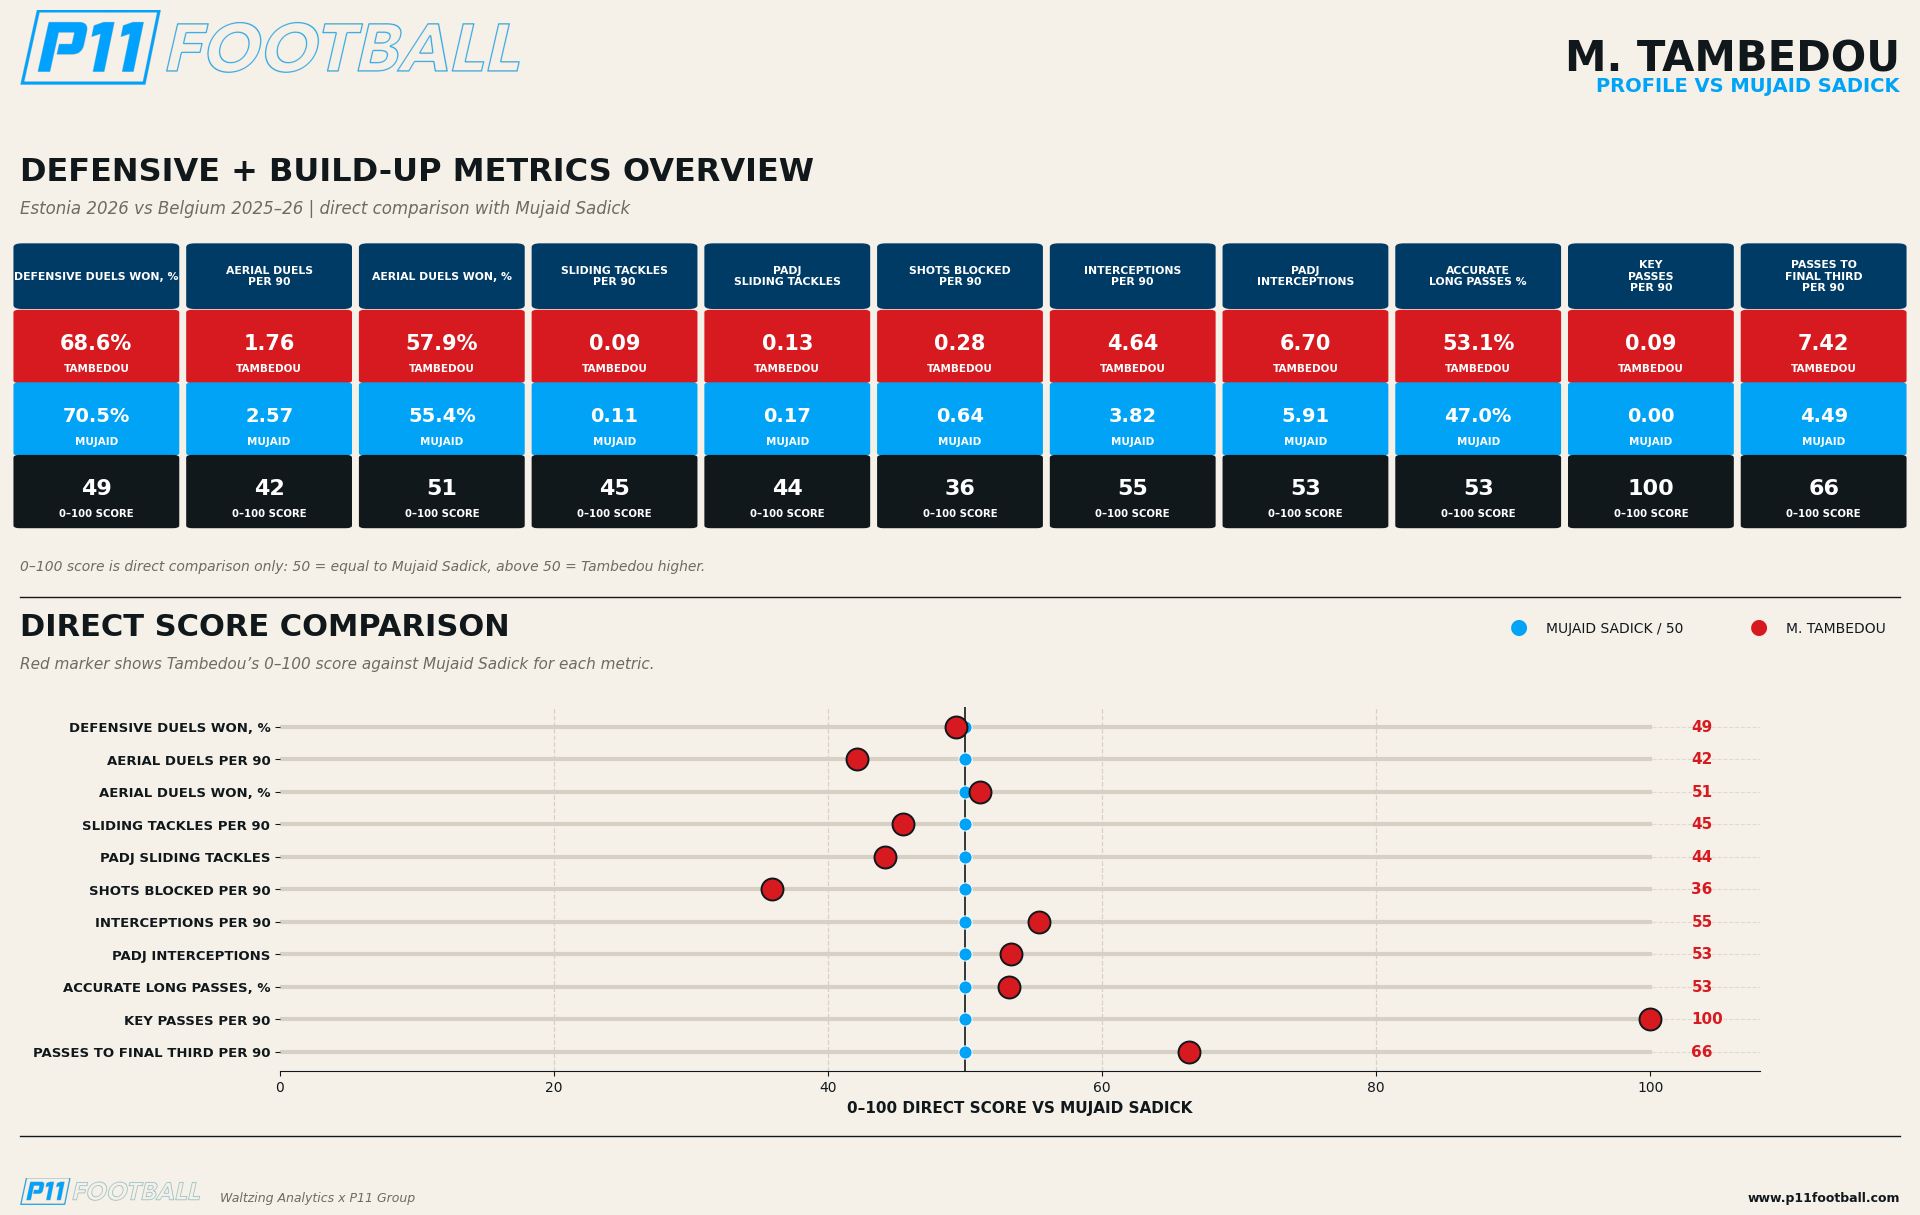

Saved to: /content/p11_tambedou_vs_mujaid_dashboard_Estonia_2026.png


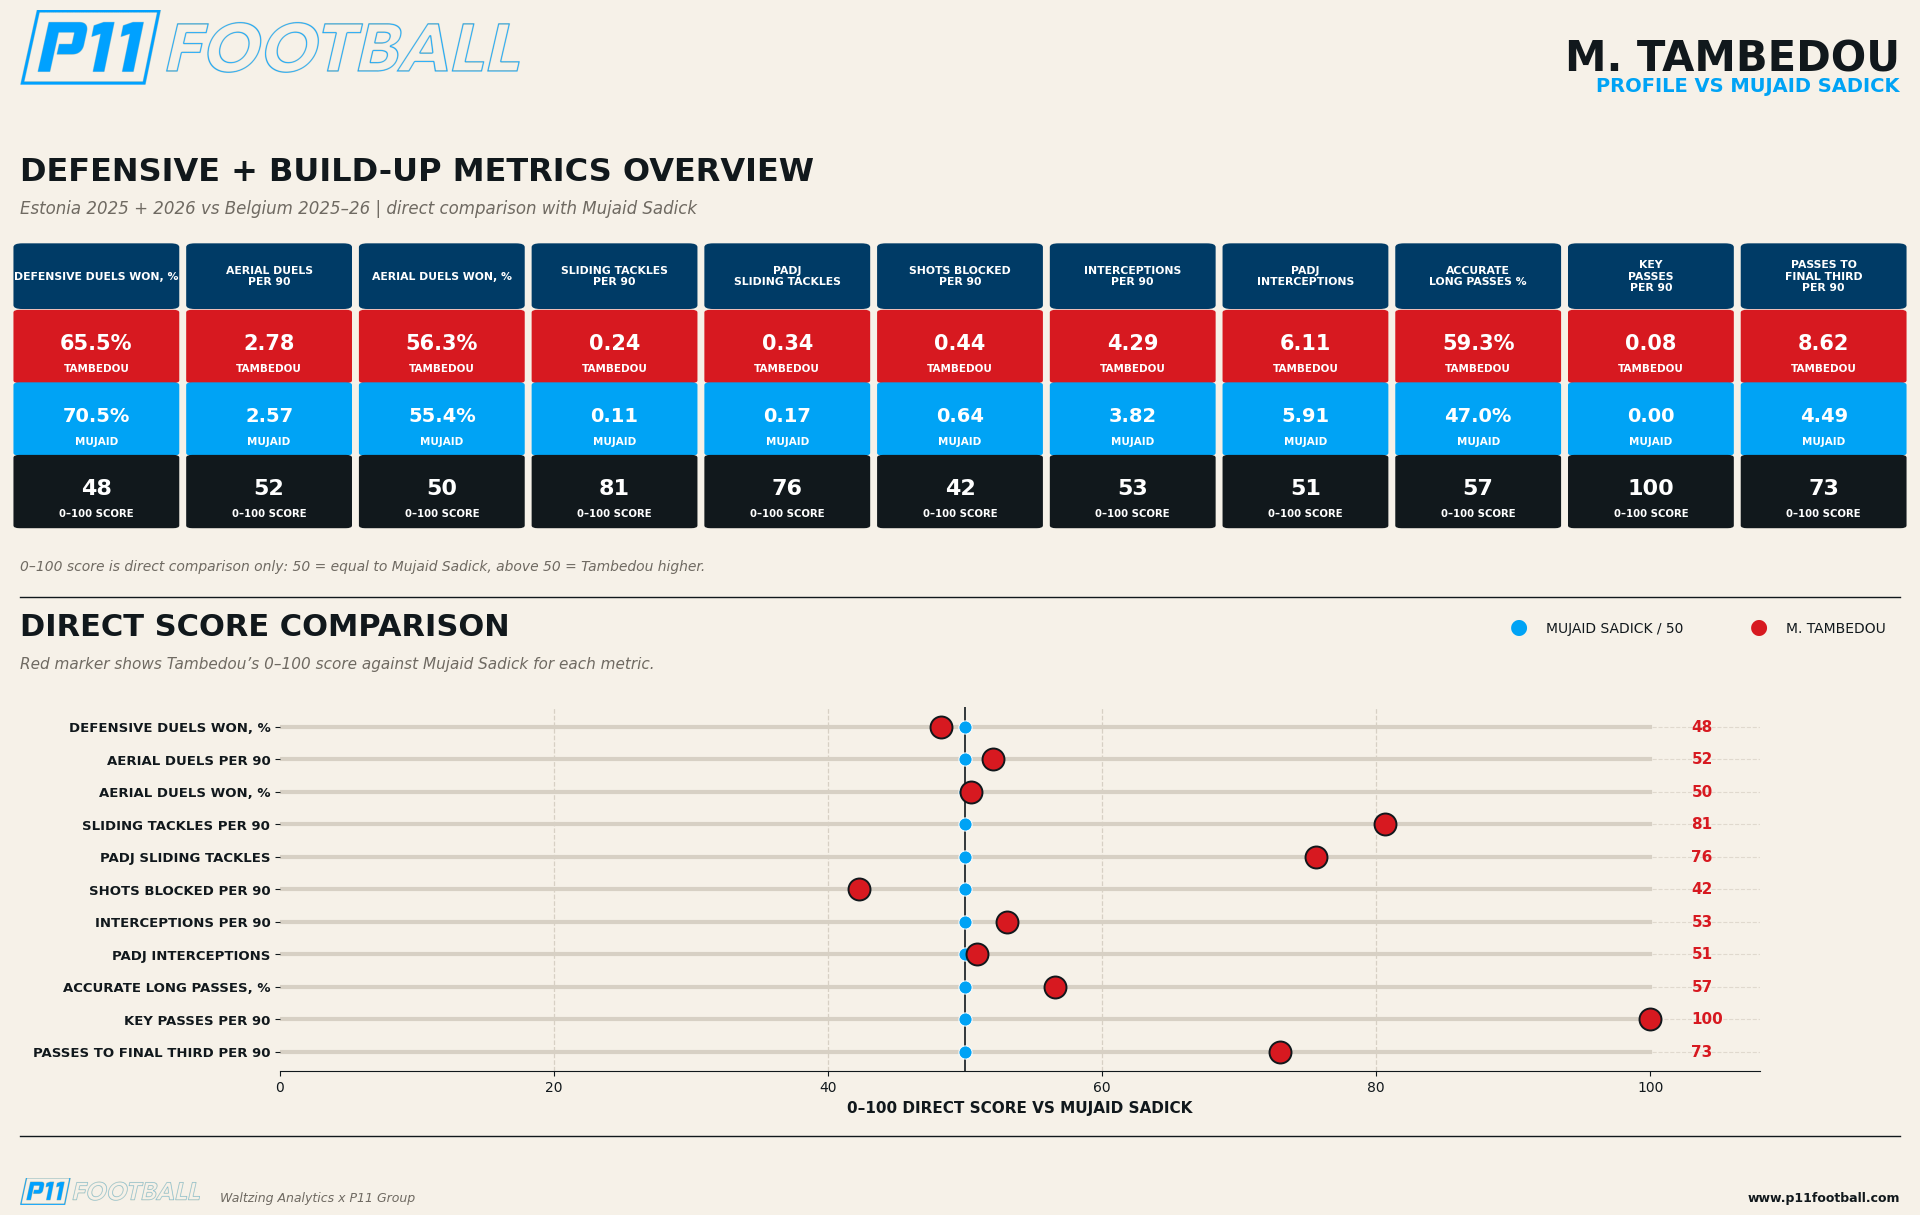

Saved to: /content/p11_tambedou_vs_mujaid_dashboard_Estonia_2025_plus_2026.png


In [14]:
# =========================
# P11-style dashboards
# 3 visuals:
# 1) Estonia 2025
# 2) Estonia 2026
# 3) Estonia 2025 + 2026
#
# M. Tambedou vs Mujaid Sadick only
# Colored metric tiles + 0–100 score strip
# No radar
# Google Colab / one cell
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageChops
from scipy.stats import norm

BASE = "/content/drive/MyDrive/P11/Wyscout/"

FILES = {
    "Belgium 2025-2026": "Belgium 2025-2026.xlsx",
    "Estonia 2025": "Estonia 2025.xlsx",
    "Estonia 2026": "Estonia 2026.xlsx",
}

LOGO_NAME = "P11-Football-Logo.png"
GENK_PLAYER = "mujaid sadick"

metrics = [
    "Defensive duels won, %",
    "Aerial duels per 90",
    "Aerial duels won, %",
    "Sliding tackles per 90",
    "PAdj Sliding tackles",
    "Shots blocked per 90",
    "Interceptions per 90",
    "PAdj Interceptions",
    "Accurate long passes, %",
    "Key passes per 90",
    "Passes to final third per 90",
]

def find_file(filename):
    direct = os.path.join(BASE, filename)
    if os.path.exists(direct):
        return direct
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Could not find: {filename}")

frames = []
for label, fn in FILES.items():
    df = pd.read_excel(find_file(fn))
    df["Dataset"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
metrics = [m for m in metrics if m in data.columns]

def trim_logo(im):
    bg_img = Image.new("RGBA", im.size, (0, 0, 0, 0))
    diff = ImageChops.difference(im, bg_img)
    bbox = diff.getbbox()
    return im.crop(bbox) if bbox else im

def add_logo_axes(fig, rect):
    try:
        logo_path = find_file(LOGO_NAME)
        logo = Image.open(logo_path).convert("RGBA")
        logo = trim_logo(logo)
        ax_logo = fig.add_axes(rect)
        ax_logo.imshow(logo)
        ax_logo.axis("off")
    except Exception as e:
        print(f"Logo error: {e}")

def clean_metric(m):
    return (
        m.upper()
        .replace(" PER 90", "\nPER 90")
        .replace("PADJ ", "PADJ\n")
        .replace("ACCURATE LONG PASSES, %", "ACCURATE\nLONG PASSES %")
        .replace("PASSES TO FINAL THIRD", "PASSES TO\nFINAL THIRD")
        .replace("KEY PASSES", "KEY\nPASSES")
    )

def weighted_profile(df, name, group):
    mins = pd.to_numeric(df["Minutes played"], errors="coerce").fillna(0)

    out = {
        "Player": name,
        "Group": group,
        "Minutes played": mins.sum()
    }

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce")
        if mins.sum() > 0:
            out[m] = np.average(vals.fillna(vals.mean()), weights=mins)
        else:
            out[m] = vals.mean()

    return out

def score_vs_single_player(tamb_val, opponent_val):
    if pd.isna(tamb_val) or pd.isna(opponent_val):
        return np.nan
    diff_ratio = (tamb_val - opponent_val) / (abs(opponent_val) + 1e-9)
    score = 50 + (diff_ratio * 25)
    return float(np.clip(score, 0, 100))

def make_dashboard(scenario_name, tambedou_datasets):
    MIN_MINUTES = 0

    tamb = data[
        (data["Player"].astype(str).str.lower().str.strip() == "m. tambedou") &
        (data["Dataset"].isin(tambedou_datasets))
    ].copy()

    opponent = data[
        (data["Dataset"] == "Belgium 2025-2026") &
        (data["Team"].astype(str).str.contains("Genk", case=False, na=False)) &
        (data["Player"].astype(str).str.lower().str.strip() == GENK_PLAYER)
    ].copy()

    tamb = tamb[pd.to_numeric(tamb["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]
    opponent = opponent[pd.to_numeric(opponent["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]

    tamb_row = weighted_profile(tamb, "M. Tambedou", "Tambedou")
    opp_row = weighted_profile(opponent, "Mujaid Sadick", "Mujaid Sadick")

    tile_rows = []

    for m in metrics:
        tamb_val = tamb_row[m]
        opp_val = opp_row[m]
        score = score_vs_single_player(tamb_val, opp_val)

        tile_rows.append({
            "Metric": m,
            "Tambedou": tamb_val,
            "Mujaid Sadick": opp_val,
            "Diff": tamb_val - opp_val,
            "Score": score
        })

    tile_df = pd.DataFrame(tile_rows)

    bg = "#F6F1E8"
    ink = "#11181C"
    muted = "#6F6A62"
    p11_blue = "#00A3F5"
    navy = "#003B66"
    red = "#D71920"
    grey = "#9A9A9A"
    light_grey = "#D7D0C4"

    plt.rcParams.update({
        "figure.facecolor": bg,
        "axes.facecolor": bg,
        "savefig.facecolor": bg,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "text.color": ink,
    })

    fig = plt.figure(figsize=(20, 13), facecolor=bg)

    add_logo_axes(fig, [0.03, 0.890, 0.25, 0.085])

    fig.text(
        0.97, 0.940,
        "M. TAMBEDOU",
        ha="right",
        va="top",
        fontsize=30,
        weight="bold",
        color=ink
    )

    fig.text(
        0.97, 0.910,
        "PROFILE VS MUJAID SADICK",
        ha="right",
        va="top",
        fontsize=14,
        weight="bold",
        color=p11_blue
    )

    fig.text(
        0.03, 0.830,
        "DEFENSIVE + BUILD-UP METRICS OVERVIEW",
        fontsize=23,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.805,
        f"{scenario_name} vs Belgium 2025–26 | direct comparison with Mujaid Sadick",
        fontsize=12,
        style="italic",
        color=muted
    )

    # =========================
    # TILE TABLE
    # =========================

    tile_ax = fig.add_axes([0.025, 0.555, 0.95, 0.235])
    tile_ax.set_xlim(0, len(metrics))
    tile_ax.set_ylim(0, 4)
    tile_ax.axis("off")

    for i, row in tile_df.iterrows():
        x = i
        m = row["Metric"]

        header = FancyBboxPatch(
            (x + 0.04, 3.02), 0.92, 0.82,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            linewidth=0,
            facecolor=navy
        )
        tile_ax.add_patch(header)

        tile_ax.text(
            x + 0.50, 3.43,
            clean_metric(m),
            ha="center",
            va="center",
            fontsize=7.8,
            weight="bold",
            color="white"
        )

        tbox = FancyBboxPatch(
            (x + 0.04, 2.05), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=red
        )
        tile_ax.add_patch(tbox)

        tile_ax.text(
            x + 0.50, 2.55,
            f"{row['Tambedou']:.2f}" if "%" not in m else f"{row['Tambedou']:.1f}%",
            ha="center",
            va="center",
            fontsize=15,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 2.22,
            "TAMBEDOU",
            ha="center",
            va="center",
            fontsize=7.5,
            weight="bold",
            color="white"
        )

        obox = FancyBboxPatch(
            (x + 0.04, 1.10), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=p11_blue
        )
        tile_ax.add_patch(obox)

        tile_ax.text(
            x + 0.50, 1.60,
            f"{row['Mujaid Sadick']:.2f}" if "%" not in m else f"{row['Mujaid Sadick']:.1f}%",
            ha="center",
            va="center",
            fontsize=14,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 1.27,
            "MUJAID",
            ha="center",
            va="center",
            fontsize=7.5,
            weight="bold",
            color="white"
        )

        score_box = FancyBboxPatch(
            (x + 0.04, 0.15), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=ink
        )
        tile_ax.add_patch(score_box)

        tile_ax.text(
            x + 0.50, 0.65,
            f"{row['Score']:.0f}",
            ha="center",
            va="center",
            fontsize=16,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 0.32,
            "0–100 SCORE",
            ha="center",
            va="center",
            fontsize=7.3,
            weight="bold",
            color="white"
        )

    fig.text(
        0.03, 0.530,
        "0–100 score is direct comparison only: 50 = equal to Mujaid Sadick, above 50 = Tambedou higher.",
        fontsize=10,
        style="italic",
        color=muted
    )

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.510, 0.510],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    # =========================
    # SCORE STRIP
    # =========================

    fig.text(
        0.03, 0.480,
        "DIRECT SCORE COMPARISON",
        fontsize=22,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.455,
        "Red marker shows Tambedou’s 0–100 score against Mujaid Sadick for each metric.",
        fontsize=11,
        style="italic",
        color=muted
    )

    ax = fig.add_axes([0.16, 0.145, 0.74, 0.28])

    for i, row in tile_df.iterrows():
        score = row["Score"]

        ax.plot([0, 100], [i, i], color=light_grey, lw=3, zorder=1)
        ax.scatter(50, i, s=90, color=p11_blue, edgecolor="white", linewidth=0.7, zorder=3)
        ax.scatter(score, i, s=250, color=red, edgecolor=ink, linewidth=1.4, zorder=5)

        ax.text(
            103,
            i,
            f"{score:.0f}",
            va="center",
            ha="left",
            fontsize=11,
            weight="bold",
            color=red
        )

    ax.axvline(50, color=ink, lw=1.2)

    for x in [20, 40, 60, 80]:
        ax.axvline(
            x,
            color=light_grey,
            lw=0.9,
            ls="--",
            zorder=1
        )

    ax.set_xlim(0, 108)
    ax.set_ylim(-0.6, len(metrics) - 0.4)

    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(
        [m.upper().replace(" PER 90", " PER 90") for m in metrics],
        fontsize=9.5,
        weight="bold"
    )

    ax.set_xlabel(
        "0–100 DIRECT SCORE VS MUJAID SADICK",
        fontsize=11,
        weight="bold"
    )

    ax.invert_yaxis()
    ax.grid(axis="y", color=light_grey, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    fig.text(0.775, 0.482, "●", color=p11_blue, fontsize=15)
    fig.text(0.793, 0.482, "MUJAID SADICK / 50", fontsize=10, color=ink)
    fig.text(0.895, 0.482, "●", color=red, fontsize=15)
    fig.text(0.913, 0.482, "M. TAMBEDOU", fontsize=10, color=ink)

    # =========================
    # FOOTER
    # =========================

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.095, 0.095],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    add_logo_axes(fig, [0.03, 0.035, 0.09, 0.035])

    fig.text(
        0.13, 0.045,
        "Waltzing Analytics x P11 Group",
        fontsize=9,
        style="italic",
        color=muted
    )

    fig.text(
        0.97, 0.045,
        "www.p11football.com",
        ha="right",
        fontsize=9,
        weight="bold",
        color=ink
    )

    safe_name = (
        scenario_name
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("–", "-")
    )

    output_path = f"/content/p11_tambedou_vs_mujaid_dashboard_{safe_name}.png"

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to: {output_path}")


SCENARIOS = {
    "Estonia 2025": ["Estonia 2025"],
    "Estonia 2026": ["Estonia 2026"],
    "Estonia 2025 + 2026": ["Estonia 2025", "Estonia 2026"],
}

for scenario_name, datasets in SCENARIOS.items():
    make_dashboard(scenario_name, datasets)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


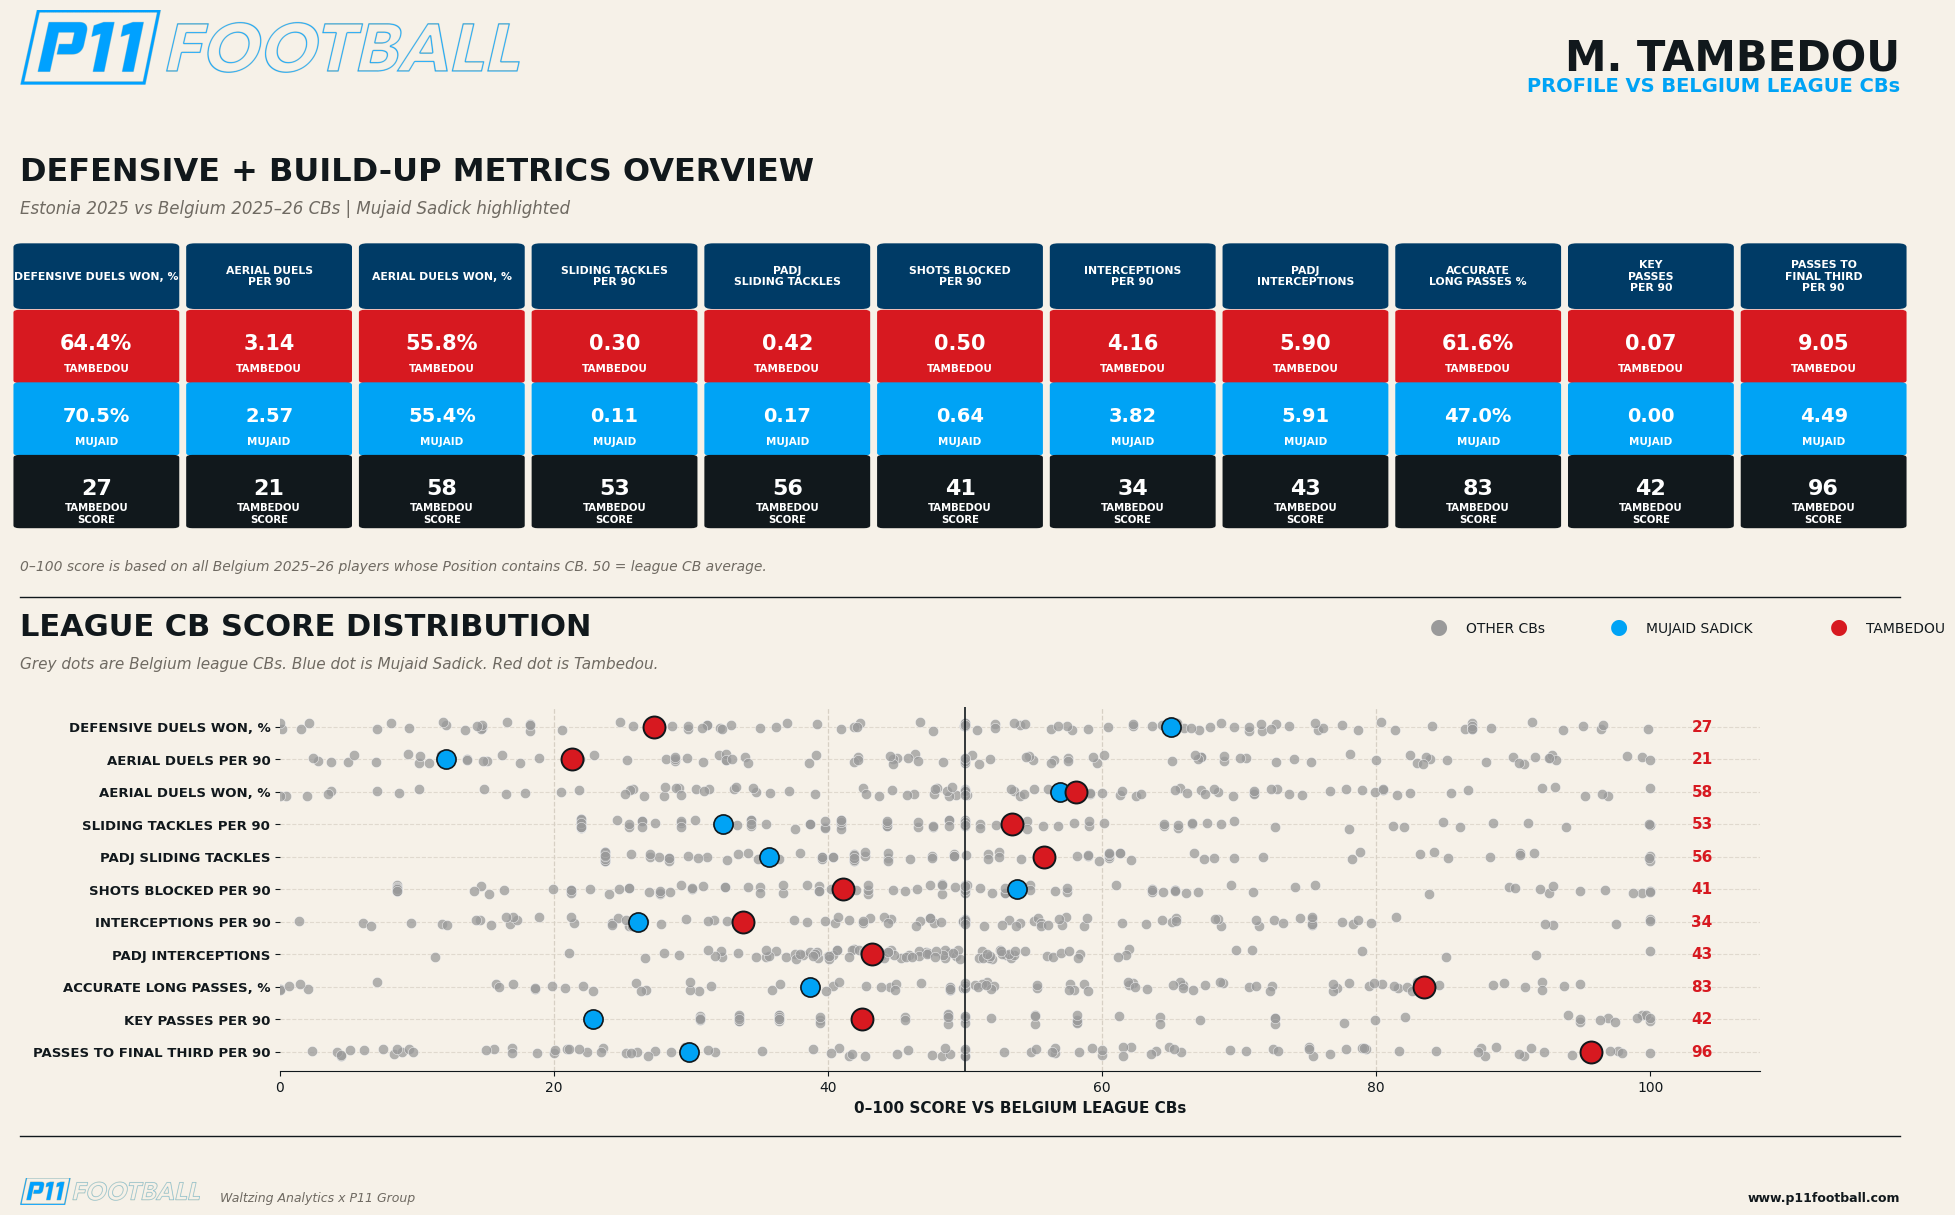

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_Estonia_2025.png


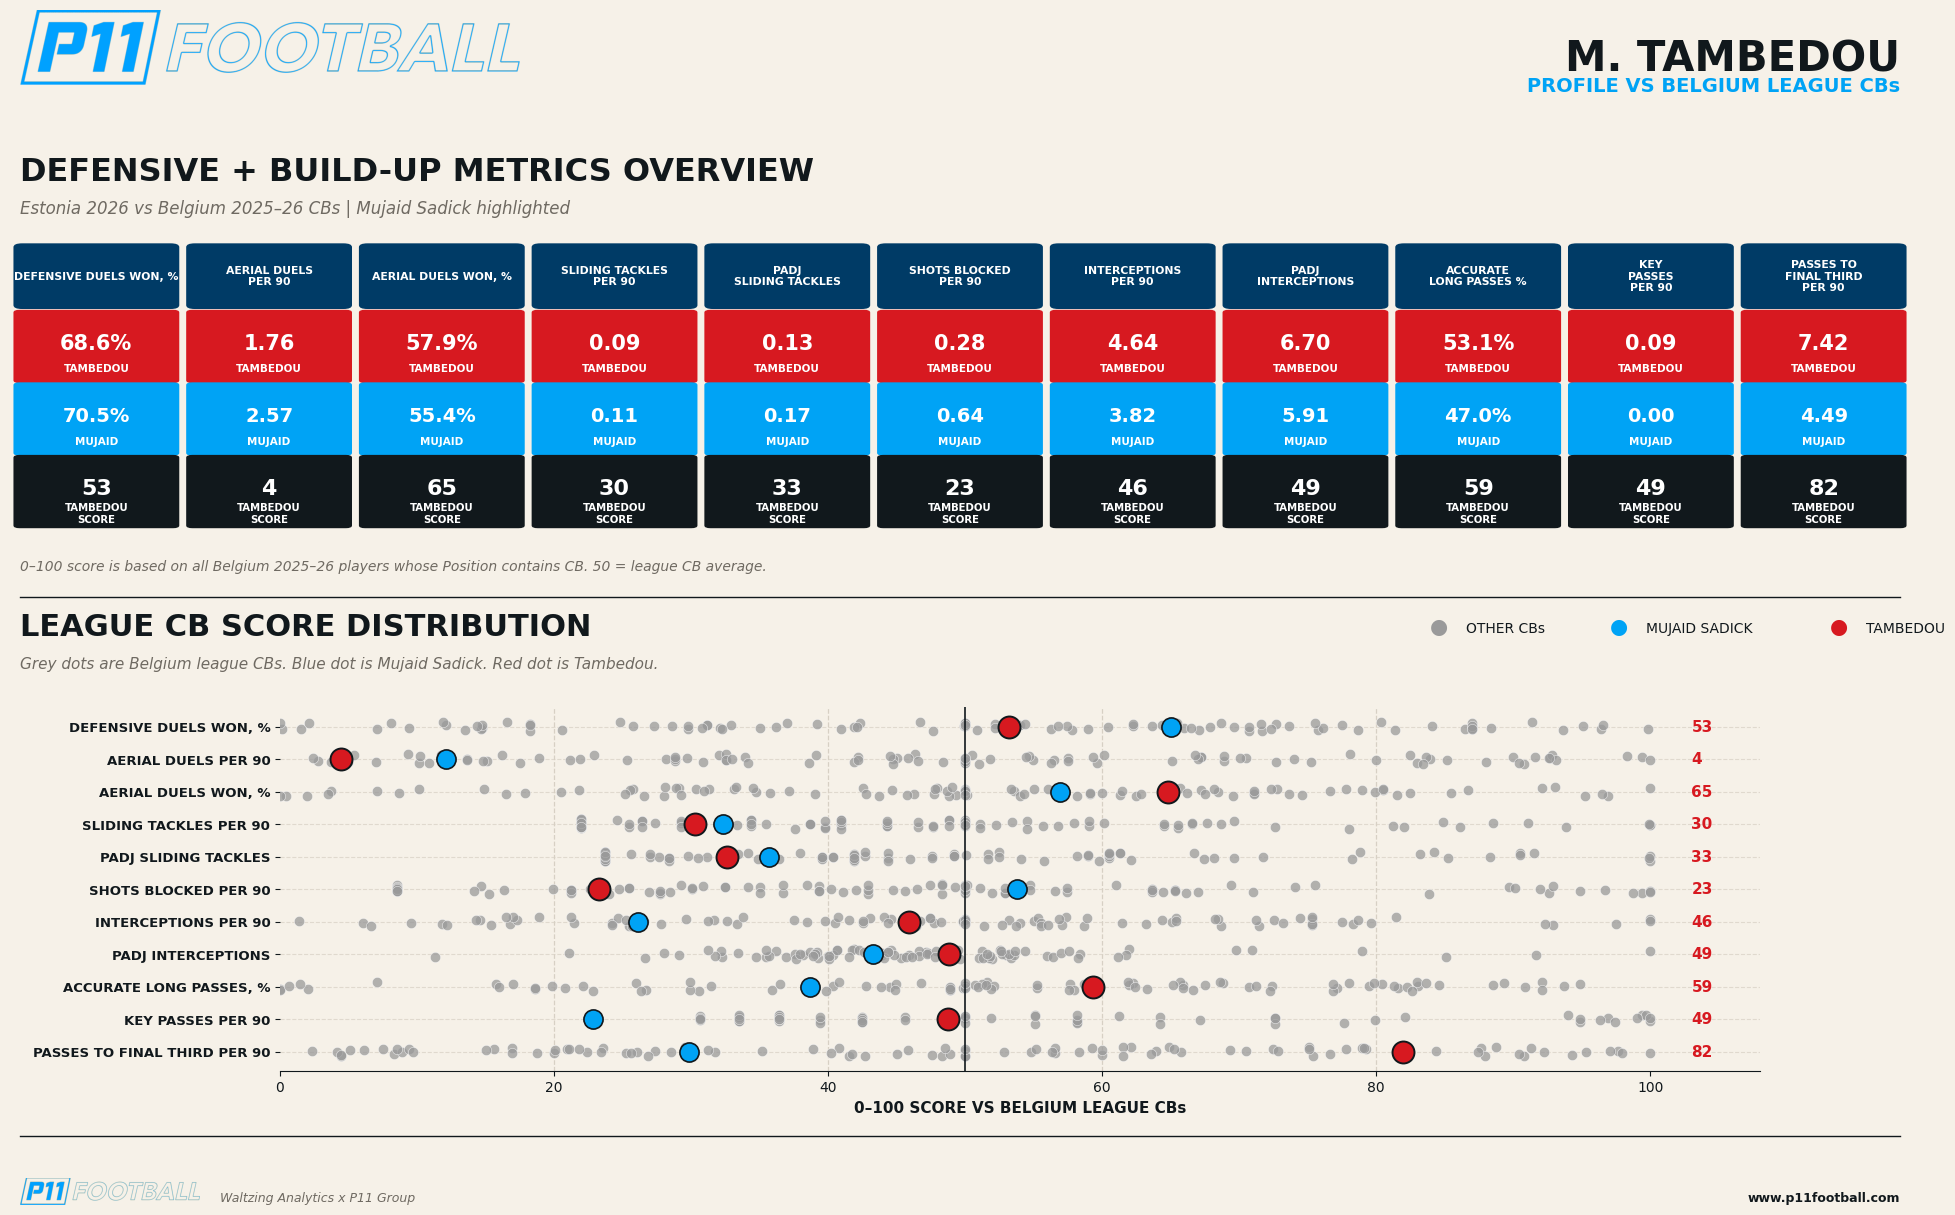

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_Estonia_2026.png


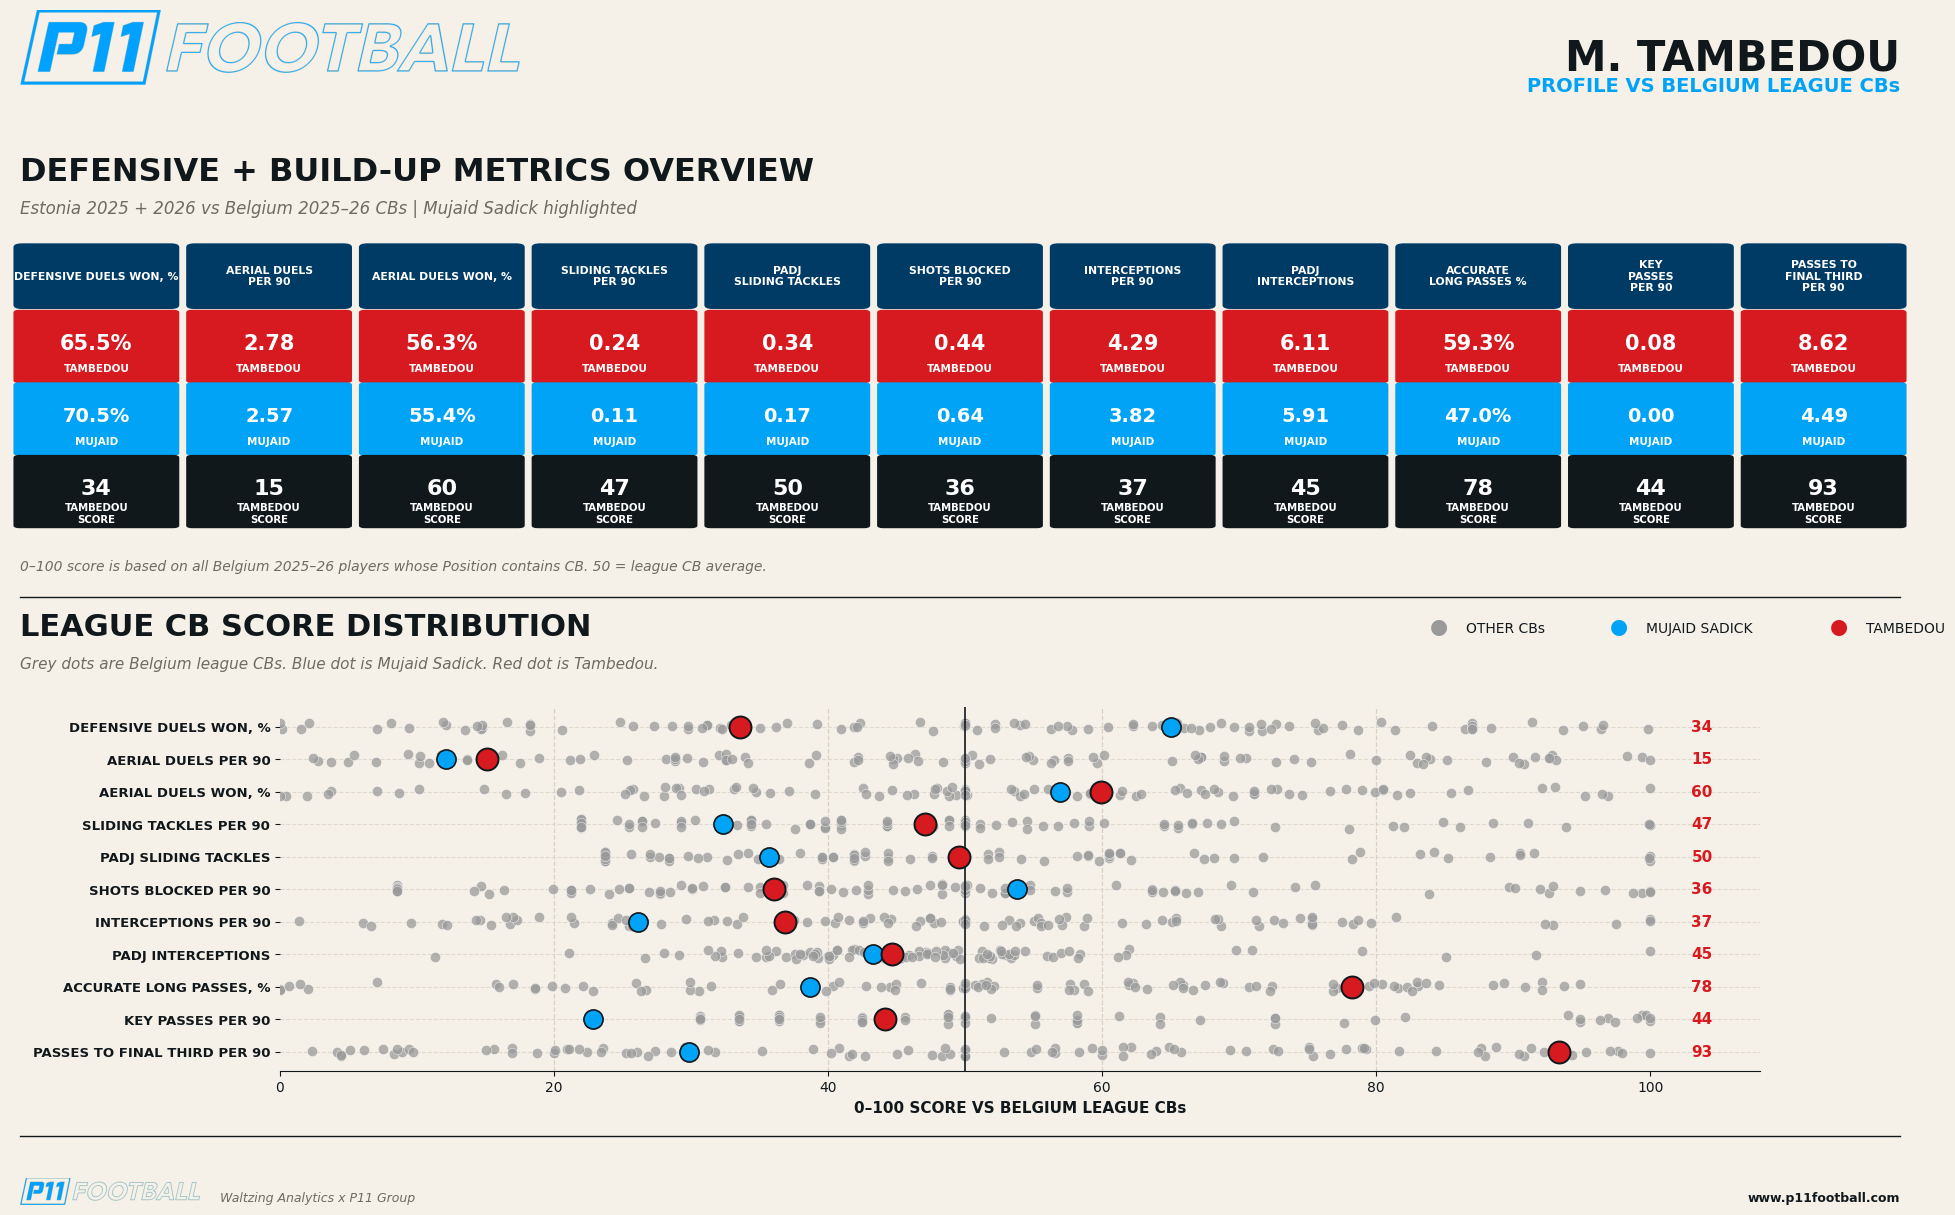

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_Estonia_2025_plus_2026.png


In [16]:
# =========================
# P11-style dashboards
# 3 visuals:
# 1) Estonia 2025
# 2) Estonia 2026
# 3) Estonia 2025 + 2026
#
# Comparison pool: ALL Belgium 2025-2026 CBs
# Red = M. Tambedou
# Blue = Mujaid Sadick
# Grey = all other league CBs
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageChops
from scipy.stats import norm

BASE = "/content/drive/MyDrive/P11/Wyscout/"

FILES = {
    "Belgium 2025-2026": "Belgium 2025-2026.xlsx",
    "Estonia 2025": "Estonia 2025.xlsx",
    "Estonia 2026": "Estonia 2026.xlsx",
}

LOGO_NAME = "P11-Football-Logo.png"
HIGHLIGHT_PLAYER = "mujaid sadick"

metrics = [
    "Defensive duels won, %",
    "Aerial duels per 90",
    "Aerial duels won, %",
    "Sliding tackles per 90",
    "PAdj Sliding tackles",
    "Shots blocked per 90",
    "Interceptions per 90",
    "PAdj Interceptions",
    "Accurate long passes, %",
    "Key passes per 90",
    "Passes to final third per 90",
]

def find_file(filename):
    direct = os.path.join(BASE, filename)
    if os.path.exists(direct):
        return direct
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Could not find: {filename}")

frames = []
for label, fn in FILES.items():
    df = pd.read_excel(find_file(fn))
    df["Dataset"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
metrics = [m for m in metrics if m in data.columns]

def is_cb(pos):
    return "CB" in str(pos).upper()

def trim_logo(im):
    bg_img = Image.new("RGBA", im.size, (0, 0, 0, 0))
    diff = ImageChops.difference(im, bg_img)
    bbox = diff.getbbox()
    return im.crop(bbox) if bbox else im

def add_logo_axes(fig, rect):
    try:
        logo_path = find_file(LOGO_NAME)
        logo = Image.open(logo_path).convert("RGBA")
        logo = trim_logo(logo)
        ax_logo = fig.add_axes(rect)
        ax_logo.imshow(logo)
        ax_logo.axis("off")
    except Exception as e:
        print(f"Logo error: {e}")

def clean_metric(m):
    return (
        m.upper()
        .replace(" PER 90", "\nPER 90")
        .replace("PADJ ", "PADJ\n")
        .replace("ACCURATE LONG PASSES, %", "ACCURATE\nLONG PASSES %")
        .replace("PASSES TO FINAL THIRD", "PASSES TO\nFINAL THIRD")
        .replace("KEY PASSES", "KEY\nPASSES")
    )

def weighted_profile(df, name, group):
    mins = pd.to_numeric(df["Minutes played"], errors="coerce").fillna(0)

    out = {
        "Player": name,
        "Group": group,
        "Minutes played": mins.sum()
    }

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce")
        if mins.sum() > 0:
            out[m] = np.average(vals.fillna(vals.mean()), weights=mins)
        else:
            out[m] = vals.mean()

    return out

def score_from_distribution(value, mean, sd):
    if pd.isna(value) or pd.isna(mean) or pd.isna(sd) or sd == 0:
        return 50
    return float(np.clip(norm.cdf((value - mean) / sd) * 100, 0, 100))

def make_dashboard(scenario_name, tambedou_datasets):
    MIN_MINUTES = 0

    tamb = data[
        (data["Player"].astype(str).str.lower().str.strip() == "m. tambedou") &
        (data["Dataset"].isin(tambedou_datasets))
    ].copy()

    league_cbs = data[
        (data["Dataset"] == "Belgium 2025-2026") &
        (data["Position"].apply(is_cb))
    ].copy()

    tamb = tamb[pd.to_numeric(tamb["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]
    league_cbs = league_cbs[pd.to_numeric(league_cbs["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]

    tamb_row = weighted_profile(tamb, "M. Tambedou", "Tambedou")

    mujaid_df = league_cbs[
        league_cbs["Player"].astype(str).str.lower().str.strip() == HIGHLIGHT_PLAYER
    ].copy()

    mujaid_row = weighted_profile(mujaid_df, "Mujaid Sadick", "Mujaid Sadick")

    tile_rows = []
    score_rows = []

    for m in metrics:
        league_vals = pd.to_numeric(league_cbs[m], errors="coerce").dropna()
        mu = league_vals.mean()
        sd = league_vals.std(ddof=0)

        tamb_val = tamb_row[m]
        mujaid_val = mujaid_row[m]

        tamb_score = score_from_distribution(tamb_val, mu, sd)
        mujaid_score = score_from_distribution(mujaid_val, mu, sd)

        tile_rows.append({
            "Metric": m,
            "Tambedou": tamb_val,
            "Mujaid Sadick": mujaid_val,
            "League CB Avg": mu,
            "Tambedou Score": tamb_score,
            "Mujaid Score": mujaid_score
        })

        for _, r in league_cbs.iterrows():
            player_val = pd.to_numeric(r[m], errors="coerce")
            player_score = score_from_distribution(player_val, mu, sd)

            group = "Mujaid Sadick" if str(r["Player"]).lower().strip() == HIGHLIGHT_PLAYER else "Other CB"

            score_rows.append({
                "Player": r["Player"],
                "Group": group,
                "Metric": m,
                "Score": player_score
            })

        score_rows.append({
            "Player": "M. Tambedou",
            "Group": "Tambedou",
            "Metric": m,
            "Score": tamb_score
        })

    tile_df = pd.DataFrame(tile_rows)
    score_df = pd.DataFrame(score_rows)

    bg = "#F6F1E8"
    ink = "#11181C"
    muted = "#6F6A62"
    p11_blue = "#00A3F5"
    navy = "#003B66"
    red = "#D71920"
    grey = "#9A9A9A"
    light_grey = "#D7D0C4"

    plt.rcParams.update({
        "figure.facecolor": bg,
        "axes.facecolor": bg,
        "savefig.facecolor": bg,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "text.color": ink,
    })

    fig = plt.figure(figsize=(20, 13), facecolor=bg)

    add_logo_axes(fig, [0.03, 0.890, 0.25, 0.085])

    fig.text(0.97, 0.940, "M. TAMBEDOU", ha="right", va="top", fontsize=30, weight="bold", color=ink)
    fig.text(0.97, 0.910, "PROFILE VS BELGIUM LEAGUE CBs", ha="right", va="top", fontsize=14, weight="bold", color=p11_blue)

    fig.text(0.03, 0.830, "DEFENSIVE + BUILD-UP METRICS OVERVIEW", fontsize=23, weight="bold", color=ink)
    fig.text(
        0.03, 0.805,
        f"{scenario_name} vs Belgium 2025–26 CBs | Mujaid Sadick highlighted",
        fontsize=12,
        style="italic",
        color=muted
    )

    tile_ax = fig.add_axes([0.025, 0.555, 0.95, 0.235])
    tile_ax.set_xlim(0, len(metrics))
    tile_ax.set_ylim(0, 4)
    tile_ax.axis("off")

    for i, row in tile_df.iterrows():
        x = i
        m = row["Metric"]

        header = FancyBboxPatch((x + 0.04, 3.02), 0.92, 0.82, boxstyle="round,pad=0.02,rounding_size=0.05", linewidth=0, facecolor=navy)
        tile_ax.add_patch(header)
        tile_ax.text(x + 0.50, 3.43, clean_metric(m), ha="center", va="center", fontsize=7.8, weight="bold", color="white")

        tbox = FancyBboxPatch((x + 0.04, 2.05), 0.92, 0.92, boxstyle="round,pad=0.02,rounding_size=0.035", linewidth=0, facecolor=red)
        tile_ax.add_patch(tbox)
        tile_ax.text(
            x + 0.50, 2.55,
            f"{row['Tambedou']:.2f}" if "%" not in m else f"{row['Tambedou']:.1f}%",
            ha="center", va="center", fontsize=15, weight="bold", color="white"
        )
        tile_ax.text(x + 0.50, 2.22, "TAMBEDOU", ha="center", va="center", fontsize=7.5, weight="bold", color="white")

        obox = FancyBboxPatch((x + 0.04, 1.10), 0.92, 0.92, boxstyle="round,pad=0.02,rounding_size=0.035", linewidth=0, facecolor=p11_blue)
        tile_ax.add_patch(obox)
        tile_ax.text(
            x + 0.50, 1.60,
            f"{row['Mujaid Sadick']:.2f}" if "%" not in m else f"{row['Mujaid Sadick']:.1f}%",
            ha="center", va="center", fontsize=14, weight="bold", color="white"
        )
        tile_ax.text(x + 0.50, 1.27, "MUJAID", ha="center", va="center", fontsize=7.5, weight="bold", color="white")

        score_box = FancyBboxPatch((x + 0.04, 0.15), 0.92, 0.92, boxstyle="round,pad=0.02,rounding_size=0.035", linewidth=0, facecolor=ink)
        tile_ax.add_patch(score_box)
        tile_ax.text(x + 0.50, 0.65, f"{row['Tambedou Score']:.0f}", ha="center", va="center", fontsize=16, weight="bold", color="white")
        tile_ax.text(x + 0.50, 0.32, "TAMBEDOU\nSCORE", ha="center", va="center", fontsize=7.3, weight="bold", color="white")

    fig.text(
        0.03, 0.530,
        "0–100 score is based on all Belgium 2025–26 players whose Position contains CB. 50 = league CB average.",
        fontsize=10,
        style="italic",
        color=muted
    )

    fig.lines.append(plt.Line2D([0.03, 0.97], [0.510, 0.510], transform=fig.transFigure, color=ink, linewidth=1))

    fig.text(0.03, 0.480, "LEAGUE CB SCORE DISTRIBUTION", fontsize=22, weight="bold", color=ink)
    fig.text(
        0.03, 0.455,
        "Grey dots are Belgium league CBs. Blue dot is Mujaid Sadick. Red dot is Tambedou.",
        fontsize=11,
        style="italic",
        color=muted
    )

    fig.text(0.735, 0.482, "●", color=grey, fontsize=15)
    fig.text(0.753, 0.482, "OTHER CBs", fontsize=10, color=ink)
    fig.text(0.825, 0.482, "●", color=p11_blue, fontsize=15)
    fig.text(0.843, 0.482, "MUJAID SADICK", fontsize=10, color=ink)
    fig.text(0.935, 0.482, "●", color=red, fontsize=15)
    fig.text(0.953, 0.482, "TAMBEDOU", fontsize=10, color=ink)

    ax = fig.add_axes([0.16, 0.145, 0.74, 0.28])

    for i, m in enumerate(metrics):
        subset = score_df[score_df["Metric"] == m].copy()

        others = subset[subset["Group"] == "Other CB"].reset_index(drop=True)
        mujaid = subset[subset["Group"] == "Mujaid Sadick"]
        tambedou = subset[subset["Group"] == "Tambedou"]

        rng = np.random.default_rng(42 + i)
        jitter = rng.uniform(-0.15, 0.15, len(others))

        ax.scatter(
            others["Score"],
            i + jitter,
            s=55,
            color=grey,
            edgecolor="white",
            linewidth=0.4,
            alpha=0.75,
            zorder=2
        )

        if len(mujaid) > 0:
            ms = float(mujaid["Score"].iloc[0])
            ax.scatter(ms, i, s=190, color=p11_blue, edgecolor=ink, linewidth=1.2, zorder=4)

        ts = float(tambedou["Score"].iloc[0])
        ax.scatter(ts, i, s=250, color=red, edgecolor=ink, linewidth=1.4, zorder=5)

        ax.text(103, i, f"{ts:.0f}", va="center", ha="left", fontsize=11, weight="bold", color=red)

    ax.axvline(50, color=ink, lw=1.2)
    for x in [20, 40, 60, 80]:
        ax.axvline(x, color=light_grey, lw=0.9, ls="--", zorder=1)

    ax.set_xlim(0, 108)
    ax.set_ylim(-0.6, len(metrics) - 0.4)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels([m.upper().replace(" PER 90", " PER 90") for m in metrics], fontsize=9.5, weight="bold")
    ax.set_xlabel("0–100 SCORE VS BELGIUM LEAGUE CBs", fontsize=11, weight="bold")

    ax.invert_yaxis()
    ax.grid(axis="y", color=light_grey, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    fig.lines.append(plt.Line2D([0.03, 0.97], [0.095, 0.095], transform=fig.transFigure, color=ink, linewidth=1))

    add_logo_axes(fig, [0.03, 0.035, 0.09, 0.035])

    fig.text(0.13, 0.045, "Waltzing Analytics x P11 Group", fontsize=9, style="italic", color=muted)
    fig.text(0.97, 0.045, "www.p11football.com", ha="right", fontsize=9, weight="bold", color=ink)

    safe_name = scenario_name.replace(" ", "_").replace("+", "plus").replace("–", "-")
    output_path = f"/content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_{safe_name}.png"

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to: {output_path}")

SCENARIOS = {
    "Estonia 2025": ["Estonia 2025"],
    "Estonia 2026": ["Estonia 2026"],
    "Estonia 2025 + 2026": ["Estonia 2025", "Estonia 2026"],
}

for scenario_name, datasets in SCENARIOS.items():
    make_dashboard(scenario_name, datasets)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


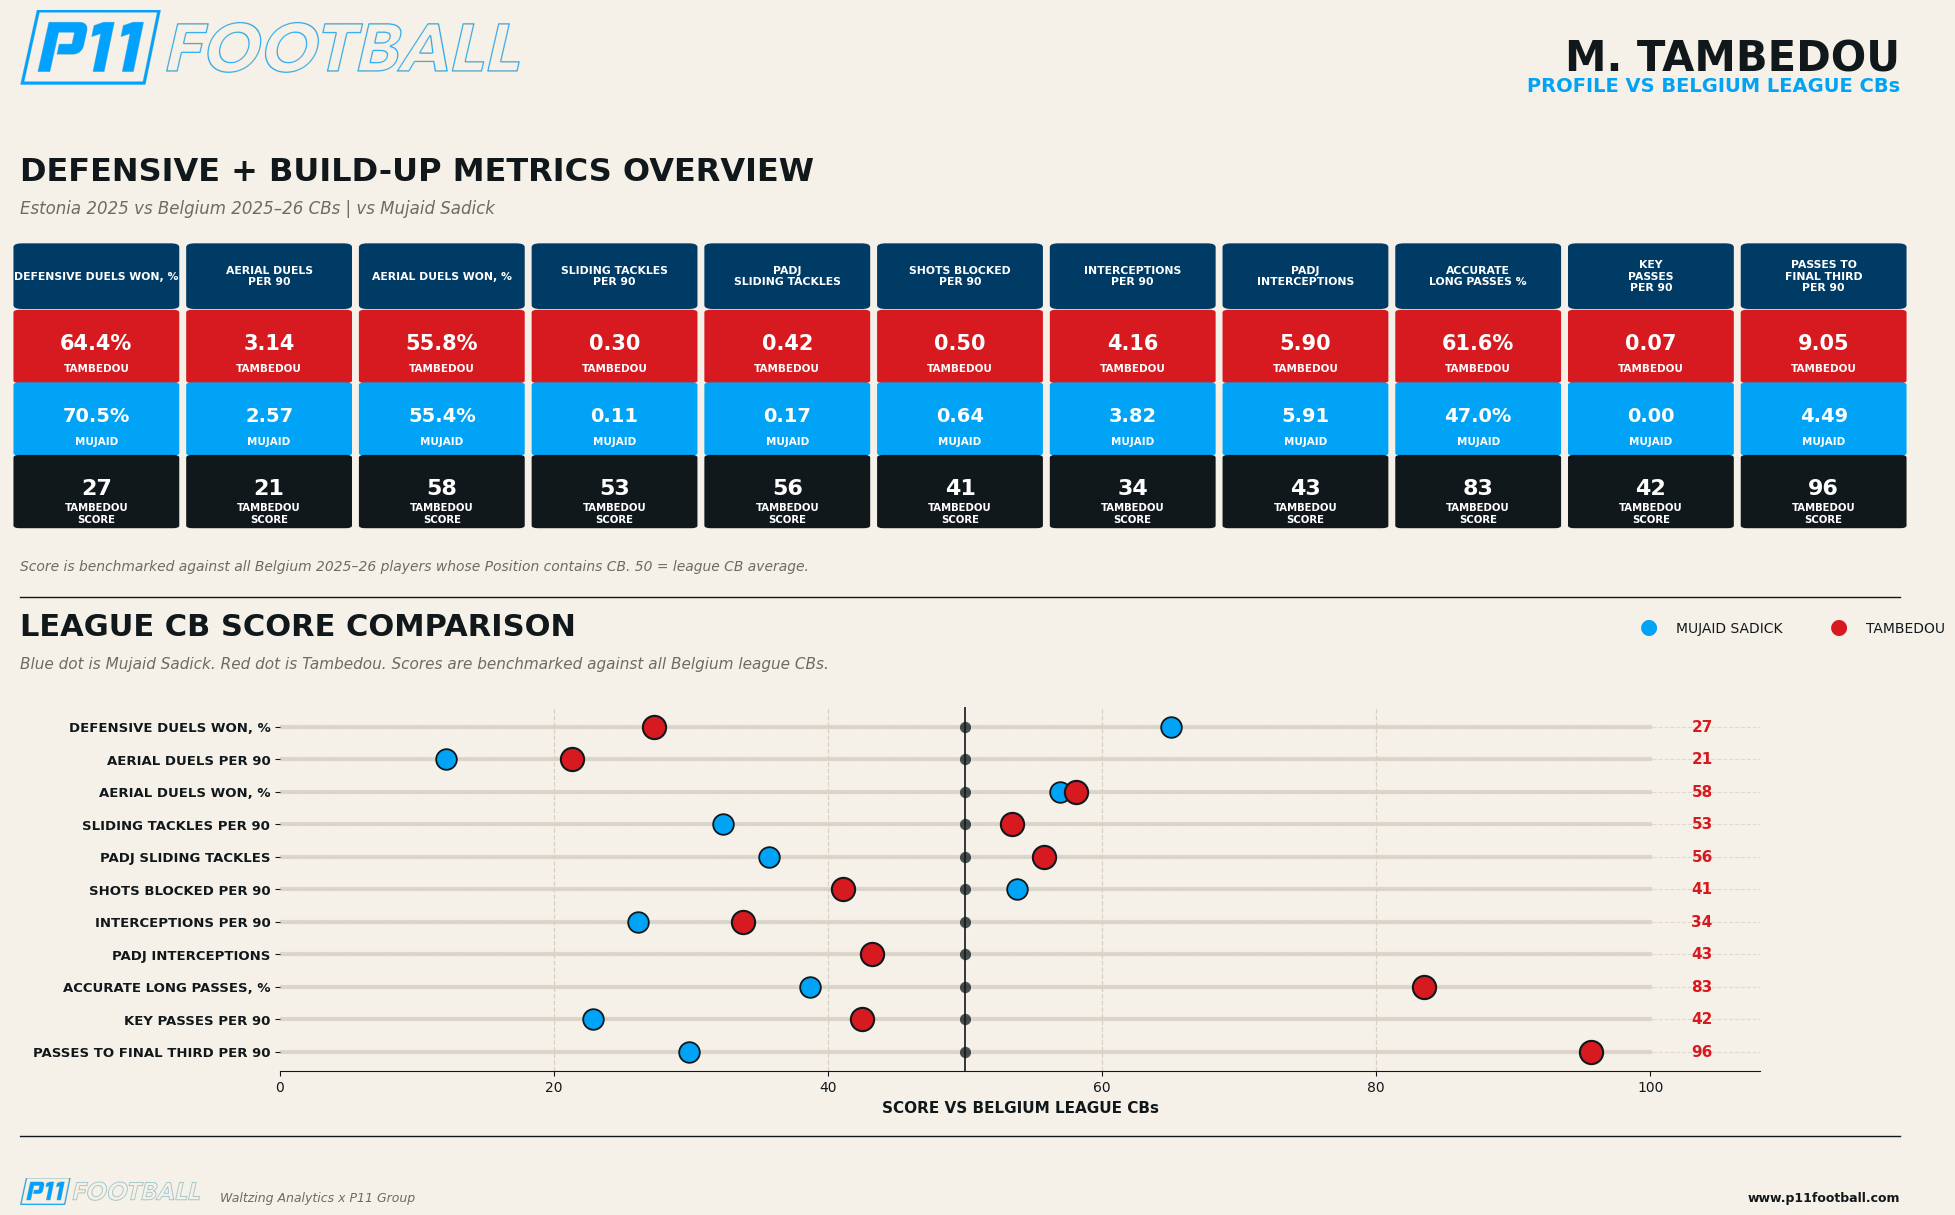

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_clean_Estonia_2025.png


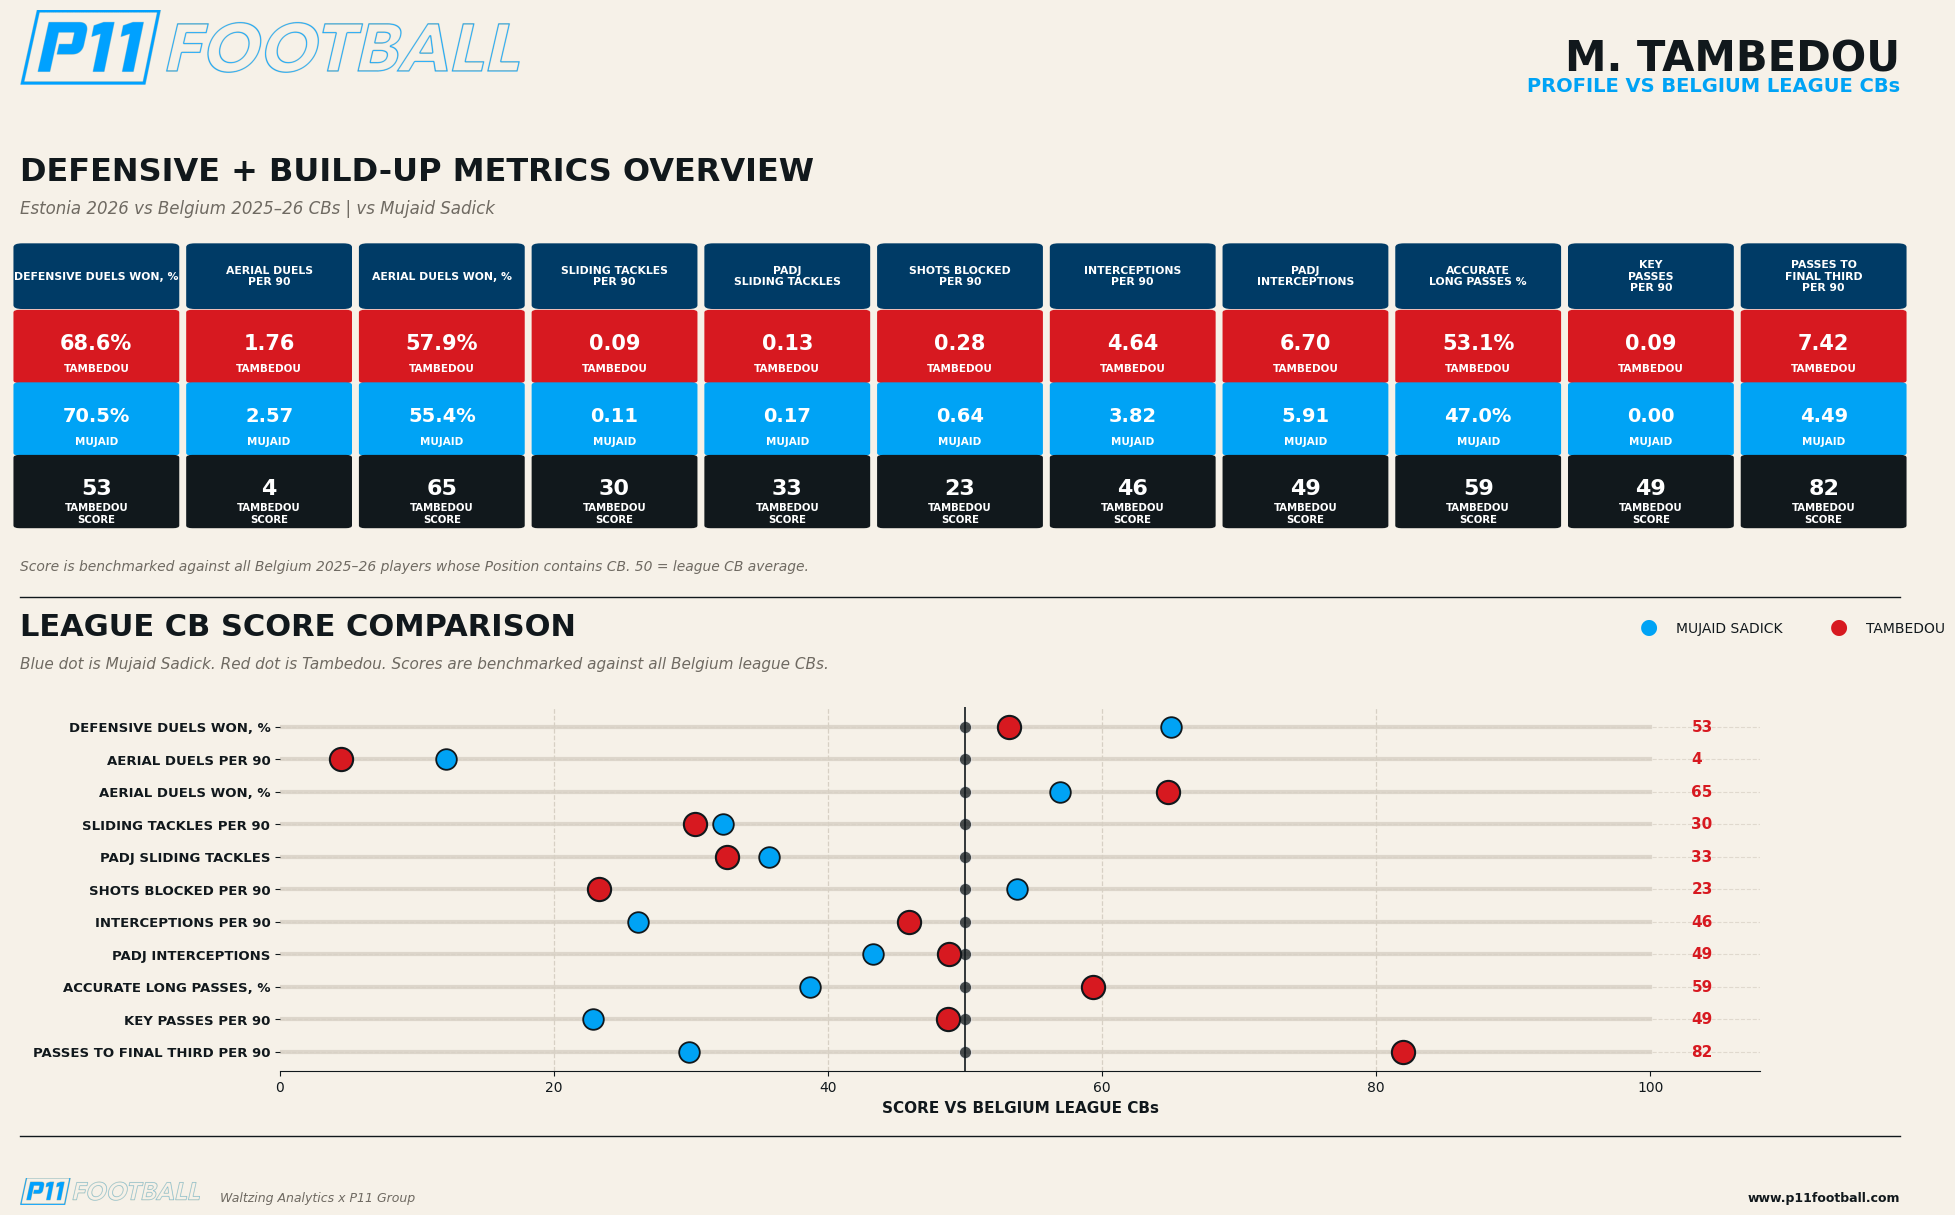

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_clean_Estonia_2026.png


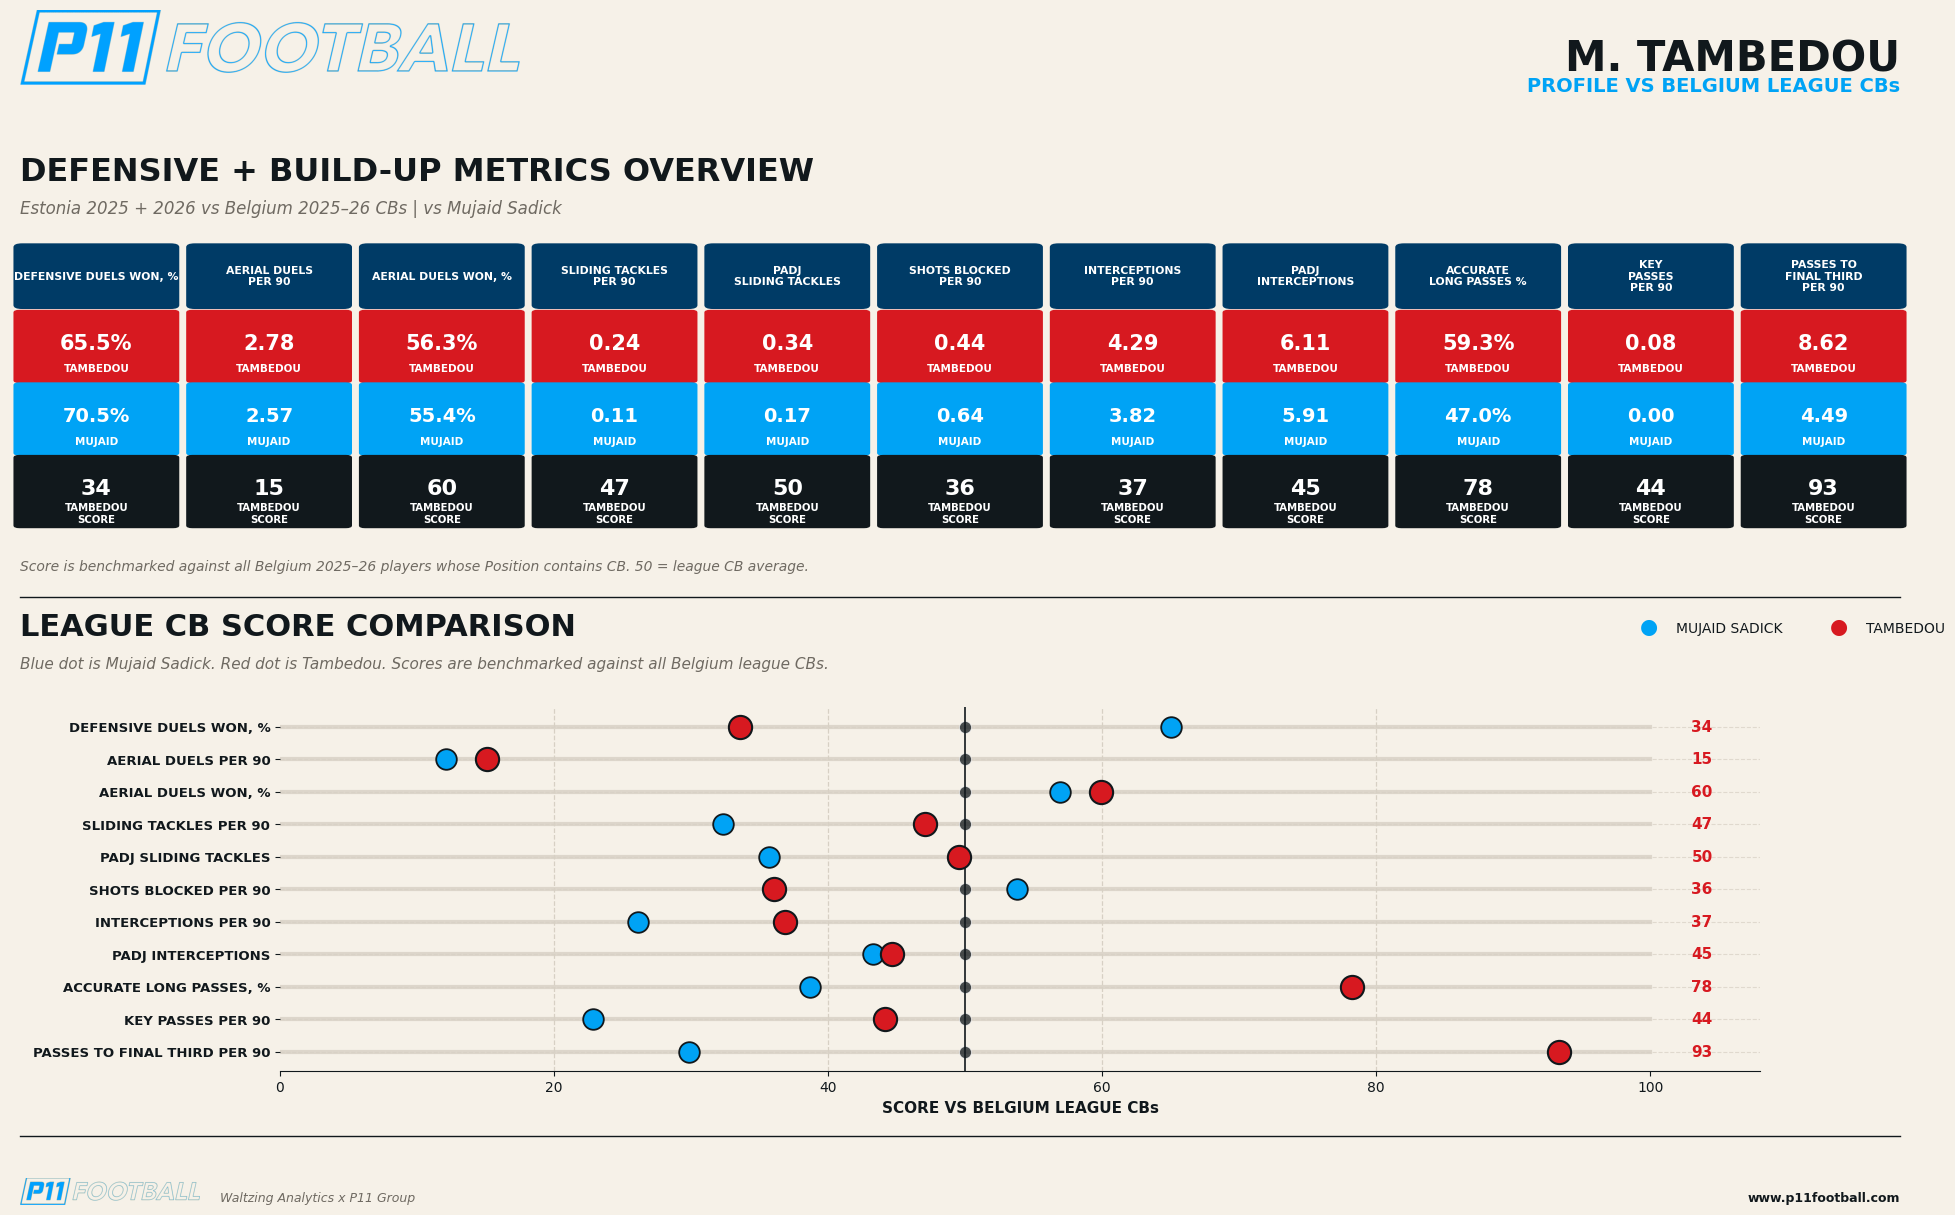

Saved to: /content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_clean_Estonia_2025_plus_2026.png


In [19]:
# =========================
# P11-style dashboards
# 3 visuals:
# 1) Estonia 2025
# 2) Estonia 2026
# 3) Estonia 2025 + 2026
#
# Benchmark pool: ALL Belgium 2025-2026 CBs
# Red = M. Tambedou
# Blue = Mujaid Sadick
# Grey dots removed
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageChops
from scipy.stats import norm

BASE = "/content/drive/MyDrive/P11/Wyscout/"

FILES = {
    "Belgium 2025-2026": "Belgium 2025-2026.xlsx",
    "Estonia 2025": "Estonia 2025.xlsx",
    "Estonia 2026": "Estonia 2026.xlsx",
}

LOGO_NAME = "P11-Football-Logo.png"
HIGHLIGHT_PLAYER = "mujaid sadick"

metrics = [
    "Defensive duels won, %",
    "Aerial duels per 90",
    "Aerial duels won, %",
    "Sliding tackles per 90",
    "PAdj Sliding tackles",
    "Shots blocked per 90",
    "Interceptions per 90",
    "PAdj Interceptions",
    "Accurate long passes, %",
    "Key passes per 90",
    "Passes to final third per 90",
]

def find_file(filename):
    direct = os.path.join(BASE, filename)
    if os.path.exists(direct):
        return direct
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Could not find: {filename}")

frames = []
for label, fn in FILES.items():
    df = pd.read_excel(find_file(fn))
    df["Dataset"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
metrics = [m for m in metrics if m in data.columns]

def is_cb(pos):
    return "CB" in str(pos).upper()

def trim_logo(im):
    bg_img = Image.new("RGBA", im.size, (0, 0, 0, 0))
    diff = ImageChops.difference(im, bg_img)
    bbox = diff.getbbox()
    return im.crop(bbox) if bbox else im

def add_logo_axes(fig, rect):
    try:
        logo_path = find_file(LOGO_NAME)
        logo = Image.open(logo_path).convert("RGBA")
        logo = trim_logo(logo)
        ax_logo = fig.add_axes(rect)
        ax_logo.imshow(logo)
        ax_logo.axis("off")
    except Exception as e:
        print(f"Logo error: {e}")

def clean_metric(m):
    return (
        m.upper()
        .replace(" PER 90", "\nPER 90")
        .replace("PADJ ", "PADJ\n")
        .replace("ACCURATE LONG PASSES, %", "ACCURATE\nLONG PASSES %")
        .replace("PASSES TO FINAL THIRD", "PASSES TO\nFINAL THIRD")
        .replace("KEY PASSES", "KEY\nPASSES")
    )

def weighted_profile(df, name, group):
    mins = pd.to_numeric(df["Minutes played"], errors="coerce").fillna(0)

    out = {
        "Player": name,
        "Group": group,
        "Minutes played": mins.sum()
    }

    for m in metrics:
        vals = pd.to_numeric(df[m], errors="coerce")
        if mins.sum() > 0:
            out[m] = np.average(vals.fillna(vals.mean()), weights=mins)
        else:
            out[m] = vals.mean()

    return out

def score_from_distribution(value, mean, sd):
    if pd.isna(value) or pd.isna(mean) or pd.isna(sd) or sd == 0:
        return 50
    return float(np.clip(norm.cdf((value - mean) / sd) * 100, 0, 100))

def make_dashboard(scenario_name, tambedou_datasets):
    MIN_MINUTES = 0

    tamb = data[
        (data["Player"].astype(str).str.lower().str.strip() == "m. tambedou") &
        (data["Dataset"].isin(tambedou_datasets))
    ].copy()

    league_cbs = data[
        (data["Dataset"] == "Belgium 2025-2026") &
        (data["Position"].apply(is_cb))
    ].copy()

    tamb = tamb[pd.to_numeric(tamb["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]
    league_cbs = league_cbs[pd.to_numeric(league_cbs["Minutes played"], errors="coerce").fillna(0) >= MIN_MINUTES]

    tamb_row = weighted_profile(tamb, "M. Tambedou", "Tambedou")

    mujaid_df = league_cbs[
        league_cbs["Player"].astype(str).str.lower().str.strip() == HIGHLIGHT_PLAYER
    ].copy()

    mujaid_row = weighted_profile(mujaid_df, "Mujaid Sadick", "Mujaid Sadick")

    tile_rows = []
    score_rows = []

    for m in metrics:
        league_vals = pd.to_numeric(league_cbs[m], errors="coerce").dropna()
        mu = league_vals.mean()
        sd = league_vals.std(ddof=0)

        tamb_val = tamb_row[m]
        mujaid_val = mujaid_row[m]

        tamb_score = score_from_distribution(tamb_val, mu, sd)
        mujaid_score = score_from_distribution(mujaid_val, mu, sd)

        tile_rows.append({
            "Metric": m,
            "Tambedou": tamb_val,
            "Mujaid Sadick": mujaid_val,
            "League CB Avg": mu,
            "Tambedou Score": tamb_score,
            "Mujaid Score": mujaid_score
        })

        score_rows.append({
            "Player": "Mujaid Sadick",
            "Group": "Mujaid Sadick",
            "Metric": m,
            "Score": mujaid_score
        })

        score_rows.append({
            "Player": "M. Tambedou",
            "Group": "Tambedou",
            "Metric": m,
            "Score": tamb_score
        })

    tile_df = pd.DataFrame(tile_rows)
    score_df = pd.DataFrame(score_rows)

    bg = "#F6F1E8"
    ink = "#11181C"
    muted = "#6F6A62"
    p11_blue = "#00A3F5"
    navy = "#003B66"
    red = "#D71920"
    light_grey = "#D7D0C4"

    plt.rcParams.update({
        "figure.facecolor": bg,
        "axes.facecolor": bg,
        "savefig.facecolor": bg,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "text.color": ink,
    })

    fig = plt.figure(figsize=(20, 13), facecolor=bg)

    add_logo_axes(fig, [0.03, 0.890, 0.25, 0.085])

    fig.text(
        0.97, 0.940,
        "M. TAMBEDOU",
        ha="right",
        va="top",
        fontsize=30,
        weight="bold",
        color=ink
    )

    fig.text(
        0.97, 0.910,
        "PROFILE VS BELGIUM LEAGUE CBs",
        ha="right",
        va="top",
        fontsize=14,
        weight="bold",
        color=p11_blue
    )

    fig.text(
        0.03, 0.830,
        "DEFENSIVE + BUILD-UP METRICS OVERVIEW",
        fontsize=23,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.805,
        f"{scenario_name} vs Belgium 2025–26 CBs | vs Mujaid Sadick",
        fontsize=12,
        style="italic",
        color=muted
    )

    # =========================
    # TILE TABLE
    # =========================

    tile_ax = fig.add_axes([0.025, 0.555, 0.95, 0.235])
    tile_ax.set_xlim(0, len(metrics))
    tile_ax.set_ylim(0, 4)
    tile_ax.axis("off")

    for i, row in tile_df.iterrows():
        x = i
        m = row["Metric"]

        header = FancyBboxPatch(
            (x + 0.04, 3.02), 0.92, 0.82,
            boxstyle="round,pad=0.02,rounding_size=0.05",
            linewidth=0,
            facecolor=navy
        )
        tile_ax.add_patch(header)

        tile_ax.text(
            x + 0.50, 3.43,
            clean_metric(m),
            ha="center",
            va="center",
            fontsize=7.8,
            weight="bold",
            color="white"
        )

        tbox = FancyBboxPatch(
            (x + 0.04, 2.05), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=red
        )
        tile_ax.add_patch(tbox)

        tile_ax.text(
            x + 0.50, 2.55,
            f"{row['Tambedou']:.2f}" if "%" not in m else f"{row['Tambedou']:.1f}%",
            ha="center",
            va="center",
            fontsize=15,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 2.22,
            "TAMBEDOU",
            ha="center",
            va="center",
            fontsize=7.5,
            weight="bold",
            color="white"
        )

        obox = FancyBboxPatch(
            (x + 0.04, 1.10), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=p11_blue
        )
        tile_ax.add_patch(obox)

        tile_ax.text(
            x + 0.50, 1.60,
            f"{row['Mujaid Sadick']:.2f}" if "%" not in m else f"{row['Mujaid Sadick']:.1f}%",
            ha="center",
            va="center",
            fontsize=14,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 1.27,
            "MUJAID",
            ha="center",
            va="center",
            fontsize=7.5,
            weight="bold",
            color="white"
        )

        score_box = FancyBboxPatch(
            (x + 0.04, 0.15), 0.92, 0.92,
            boxstyle="round,pad=0.02,rounding_size=0.035",
            linewidth=0,
            facecolor=ink
        )
        tile_ax.add_patch(score_box)

        tile_ax.text(
            x + 0.50, 0.65,
            f"{row['Tambedou Score']:.0f}",
            ha="center",
            va="center",
            fontsize=16,
            weight="bold",
            color="white"
        )

        tile_ax.text(
            x + 0.50, 0.32,
            "TAMBEDOU\nSCORE",
            ha="center",
            va="center",
            fontsize=7.3,
            weight="bold",
            color="white"
        )

    fig.text(
        0.03, 0.530,
        "Score is benchmarked against all Belgium 2025–26 players whose Position contains CB. 50 = league CB average.",
        fontsize=10,
        style="italic",
        color=muted
    )

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.510, 0.510],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    # =========================
    # CLEAN SCORE STRIP
    # =========================

    fig.text(
        0.03, 0.480,
        "LEAGUE CB SCORE COMPARISON",
        fontsize=22,
        weight="bold",
        color=ink
    )

    fig.text(
        0.03, 0.455,
        "Blue dot is Mujaid Sadick. Red dot is Tambedou. Scores are benchmarked against all Belgium league CBs.",
        fontsize=11,
        style="italic",
        color=muted
    )

    fig.text(0.84, 0.482, "●", color=p11_blue, fontsize=15)
    fig.text(0.858, 0.482, "MUJAID SADICK", fontsize=10, color=ink)

    fig.text(0.935, 0.482, "●", color=red, fontsize=15)
    fig.text(0.953, 0.482, "TAMBEDOU", fontsize=10, color=ink)

    ax = fig.add_axes([0.16, 0.145, 0.74, 0.28])

    for i, m in enumerate(metrics):
        subset = score_df[score_df["Metric"] == m].copy()

        mujaid = subset[subset["Group"] == "Mujaid Sadick"]
        tambedou = subset[subset["Group"] == "Tambedou"]

        # horizontal comparison line
        ax.plot(
            [0, 100],
            [i, i],
            color=light_grey,
            lw=3,
            alpha=0.8,
            zorder=1
        )

        # league average marker
        ax.scatter(
            50,
            i,
            s=75,
            color=ink,
            edgecolor="white",
            linewidth=0.6,
            alpha=0.75,
            zorder=2
        )

        # Mujaid Sadick
        if len(mujaid) > 0:
            ms = float(mujaid["Score"].iloc[0])
            ax.scatter(
                ms,
                i,
                s=220,
                color=p11_blue,
                edgecolor=ink,
                linewidth=1.3,
                zorder=4
            )

        # Tambedou
        ts = float(tambedou["Score"].iloc[0])
        ax.scatter(
            ts,
            i,
            s=280,
            color=red,
            edgecolor=ink,
            linewidth=1.5,
            zorder=5
        )

        ax.text(
            103,
            i,
            f"{ts:.0f}",
            va="center",
            ha="left",
            fontsize=11,
            weight="bold",
            color=red
        )

    ax.axvline(50, color=ink, lw=1.2)

    for x in [20, 40, 60, 80]:
        ax.axvline(
            x,
            color=light_grey,
            lw=0.9,
            ls="--",
            zorder=1
        )

    ax.set_xlim(0, 108)
    ax.set_ylim(-0.6, len(metrics) - 0.4)

    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(
        [m.upper().replace(" PER 90", " PER 90") for m in metrics],
        fontsize=9.5,
        weight="bold"
    )

    ax.set_xlabel(
        "SCORE VS BELGIUM LEAGUE CBs",
        fontsize=11,
        weight="bold"
    )

    ax.invert_yaxis()

    ax.grid(
        axis="y",
        color=light_grey,
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # =========================
    # FOOTER
    # =========================

    fig.lines.append(
        plt.Line2D(
            [0.03, 0.97],
            [0.095, 0.095],
            transform=fig.transFigure,
            color=ink,
            linewidth=1
        )
    )

    add_logo_axes(fig, [0.03, 0.035, 0.09, 0.035])

    fig.text(
        0.13, 0.045,
        "Waltzing Analytics x P11 Group",
        fontsize=9,
        style="italic",
        color=muted
    )

    fig.text(
        0.97, 0.045,
        "www.p11football.com",
        ha="right",
        fontsize=9,
        weight="bold",
        color=ink
    )

    safe_name = scenario_name.replace(" ", "_").replace("+", "plus").replace("–", "-")
    output_path = f"/content/drive/MyDrive/P11/p11_tambedou_vs_belgium_cbs_clean_{safe_name}.png"

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved to: {output_path}")

SCENARIOS = {
    "Estonia 2025": ["Estonia 2025"],
    "Estonia 2026": ["Estonia 2026"],
    "Estonia 2025 + 2026": ["Estonia 2025", "Estonia 2026"],
}

for scenario_name, datasets in SCENARIOS.items():
    make_dashboard(scenario_name, datasets)